In [ ]:
import numpy as np

In [ ]:
path_sgd = "outputs/exp_16_20241208-065028_SGD_MNIST_one_layer"
path_svrg = "outputs/exp_17_20241208-064518_SVRG_MNIST_one_layer"
train_loss_sgd, train_acc_sgd, weights_sgd, grads_sgd = np.load(path_sgd+"/train_stats.npz", allow_pickle=True).values()
train_loss_svrg, train_acc_svrg, weights_svrg, grads_svrg = np.load(path_svrg+"/train_stats.npz", allow_pickle=True).values()

In [ ]:
a = "--optimizer SVRG --dataset CIFAR10 --nn_model CIFAR10_convnet --lr 0.05 --log --device cuda:5 --batch_size 5 --temperature 5 --ratio 0.1"
lista = a.split(' ')
# print and " not using '
import json
print(json.dumps(lista, indent=4))·

[
    "--optimizer",
    "SVRG",
    "--dataset",
    "CIFAR10",
    "--nn_model",
    "CIFAR10_convnet",
    "--lr",
    "0.05",
    "--log",
    "--device",
    "cuda:5",
    "--batch_size",
    "5",
    "--temperature",
    "5",
    "--ratio",
    "0.1"
]


In [5]:
grads_svrg

array([0.89977956, 0.96876013, 0.79886226, 0.65859927, 0.549972  ,
       0.46867074, 0.4073971 , 0.36020979, 0.32258594, 0.29202372,
       0.26669062, 0.2453949 , 0.22725551, 0.21162502, 0.19800987,
       0.18604316, 0.17544683, 0.166     , 0.15752743, 0.14988562,
       0.1429525 , 0.13663758, 0.13085999, 0.12555541, 0.12066987,
       0.11615169, 0.11196444, 0.10807024, 0.10444132, 0.10105132,
       0.09787743, 0.09489885, 0.09209889, 0.08946121, 0.08697294,
       0.08462087, 0.082395  , 0.08028537, 0.0782828 , 0.07637946,
       0.07456881, 0.07284318, 0.07119754, 0.06962551, 0.06812301,
       0.06668474, 0.06530738, 0.06398711, 0.06272052, 0.0615043 ,
       0.06033487, 0.05921031, 0.0581272 , 0.05708425, 0.05607906,
       0.05510968, 0.05417327, 0.05326907, 0.05239491, 0.05155004,
       0.0507328 , 0.04994136, 0.04917474, 0.04843269, 0.04771253,
       0.04701379, 0.04633556, 0.04567807, 0.04503838, 0.04441726,
       0.04381325, 0.04322555, 0.04265403, 0.04209811, 0.04155

In [22]:
import matplotlib.pyplot as plt
import os
def plot_train_stats(train_loss_1, train_acc_1, train_grad_norms_1, train_loss_2, train_acc_2, train_grad_norms_2, directory, acc_low=0.2):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(8,2.5))
    axes[0].plot(np.array(train_loss_1), label="SGD")
    axes[0].plot(np.array(train_loss_2), label="SVRG")
    axes[0].set_title("Train loss")
    axes[0].legend()
    axes[1].plot(np.array(train_acc_1), label="SGD")
    axes[1].plot(np.array(train_acc_2), label="SVRG")
    axes[1].set_ylim(acc_low, 1)
    axes[1].set_title("Train Accuracy")
    axes[1].legend()
    axes[2].plot(np.array(train_grad_norms_1), label="SGD")
    axes[2].plot(np.array(train_grad_norms_2), label="SVRG")
    axes[2].set_title("Train Gradient Norms")
    # set a log yticks: 10**(-3) to 10**(0)
    axes[2].set_yscale('log')
    axes[2].legend()
    # add a global x axis
    for ax in axes:
        ax.set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig(os.path.join(directory, 'train_stats.pdf'))

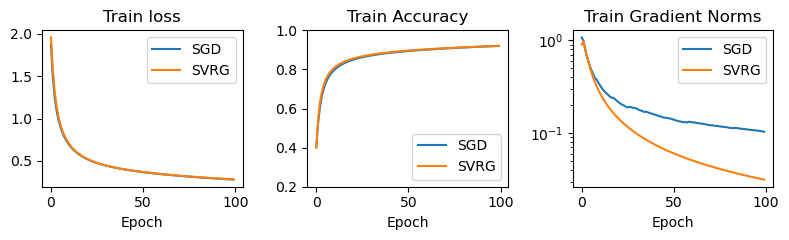

In [23]:
plot_train_stats(train_loss_sgd, train_acc_sgd, grads_sgd, train_loss_svrg, train_acc_svrg, grads_svrg, "plots")

In [4]:
# test the model latency 
latency = 10
batchsize = 256
n = 50000
n_batches = n // batchsize
one_epoch_time = n_batches * latency
epochs = 100
print(one_epoch_time * epochs / 3600 /24, "days")


2.256944444444444


In [3]:
# SGD result check 
sgd_mnist_path = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250121-161048_SGD_one_layer_Temperature5.0_lr0.003"
svrg_mnist_path = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250121-161058_SVRG_one_layer_Temperature5.0_lr0.003"
import pandas as pd
import os 
df1 = pd.read_csv(os.path.join(sgd_mnist_path, "train_stats.csv"))
df2 = pd.read_csv(os.path.join(svrg_mnist_path, "train_stats.csv"))


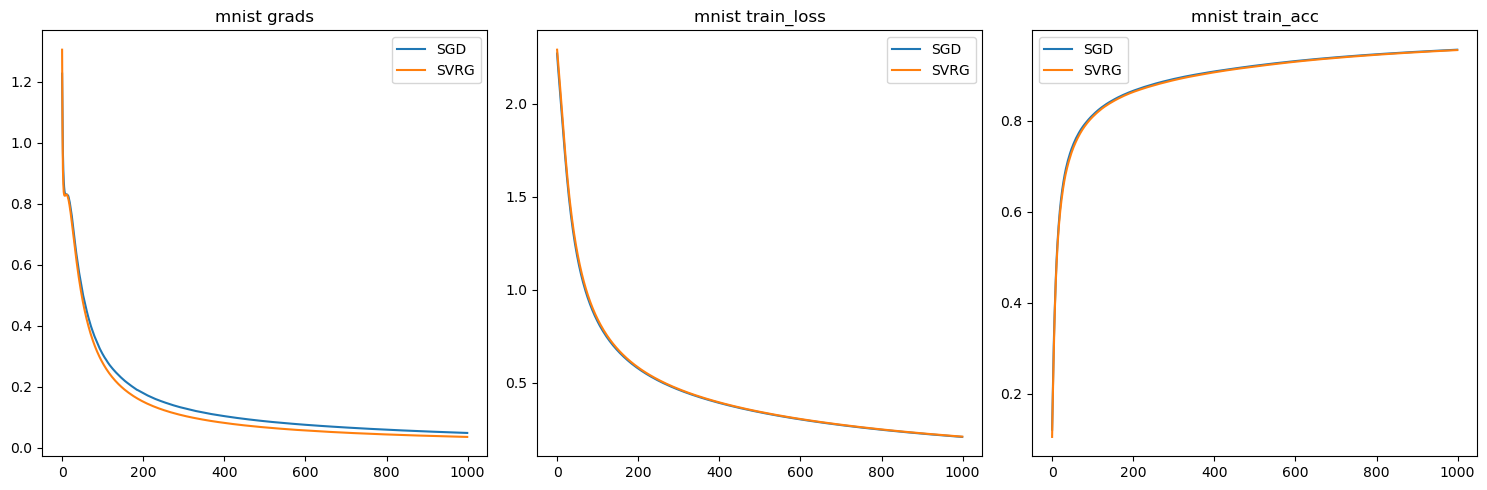

In [4]:
import matplotlib.pyplot as plt

def plot_columns(columns, df1, df2, title=None, slice=None):
    if slice:
        df1 = df1[:slice]
        df2 = df2[:slice]

    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    

    if len(columns) == 1:
        axes = [axes]
    
    for i, column in enumerate(columns):
        axes[i].plot(df1[column], label="SGD")
        axes[i].plot(df2[column], label="SVRG")
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    
    plt.tight_layout()
    
    plt.show()


plot_columns(["grads", "train_loss", "train_acc"], df1, df2, 'mnist')

In [1]:
SVRG_CIFAR = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250115-202038_SVRG_CIFAR10_convnet_Temperature5.0_lr0.005"
SGD_CIFAR = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250115-202043_SGD_CIFAR10_convnet_Temperature5.0_lr0.005"
import pandas as pd
import os 
df1 = pd.read_csv(os.path.join(SGD_CIFAR, "train_stats.csv"))
df2 = pd.read_csv(os.path.join(SVRG_CIFAR, "train_stats.csv"))

In [4]:
SVRG_CIFAR = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250117-094202_SVRG_CIFAR10_convnet_Temperature5.0_lr0.008"
SGD_CIFAR = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250117-094156_SGD_CIFAR10_convnet_Temperature5.0_lr0.008"
import pandas as pd
import os 
df1 = pd.read_csv(os.path.join(SGD_CIFAR, "train_stats.csv"))
df2 = pd.read_csv(os.path.join(SVRG_CIFAR, "train_stats.csv"))

In [1]:
SVRG_CIFAR = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250123-160602_SVRG_CIFAR10_convnet_Temperature5.0_lr0.005"
SGD_CIFAR = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250123-160602_SGD_CIFAR10_convnet_Temperature5.0_lr0.005"
import pandas as pd
import os 
df1 = pd.read_csv(os.path.join(SGD_CIFAR, "train_stats.csv"))
df2 = pd.read_csv(os.path.join(SVRG_CIFAR, "train_stats.csv"))

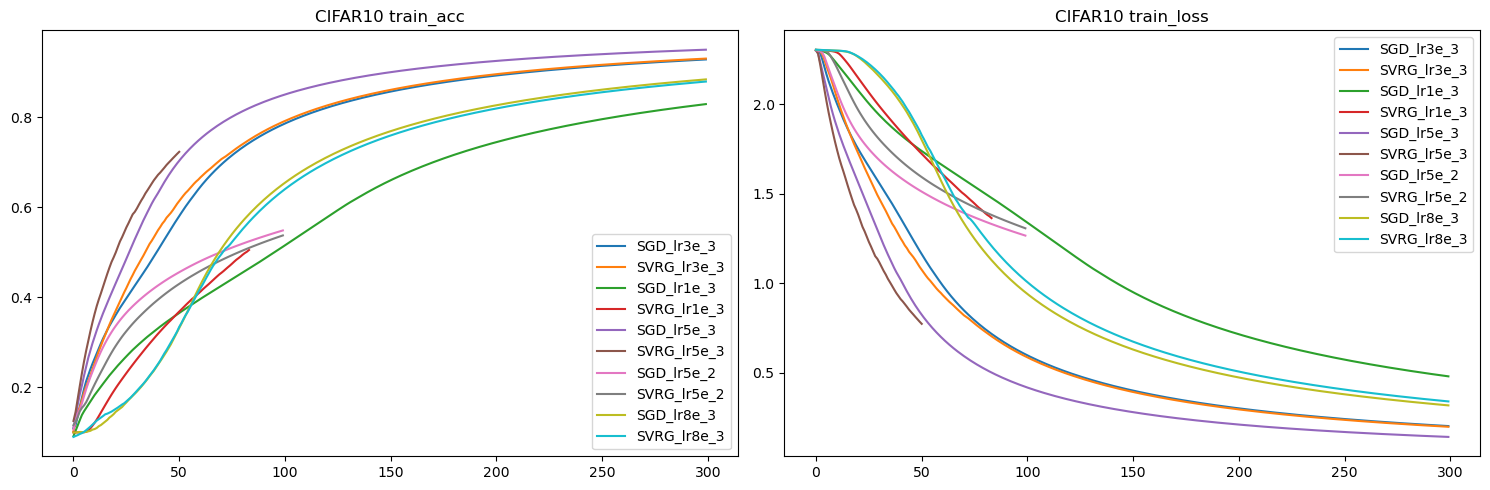

In [10]:

SVRG_lr1e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-083029_SVRG_CIFAR10_convnet_Temperature5.0_lr0.01'
SGD_lr1e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-083039_SGD_CIFAR10_convnet_Temperature5.0_lr0.01'

SVRG_lr3e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013104_SVRG_CIFAR10_convnet_Temperature5.0_lr0.003'
SGD_lr3e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013055_SGD_CIFAR10_convnet_Temperature5.0_lr0.003'

# SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013318_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
# SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013311_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'
SVRG_lr5e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250113-114335_SVRG_CIFAR10_convnet_Temperature5.0_lr0.01'
SGD_lr5e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250113-114339_SGD_CIFAR10_convnet_Temperature5.0_lr0.01'

SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250212-110925_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-083004_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'

SVRG_lr5e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250122-223552_SVRG_CIFAR10_convnet_Temperature5.0_lr0.005'
SGD_lr5e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250123-160602_SGD_CIFAR10_convnet_Temperature5.0_lr0.005'

SVRG_lr8e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250122-180713_SVRG_CIFAR10_convnet_Temperature5.0_lr0.008'
SGD_lr8e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250122-180727_SGD_CIFAR10_convnet_Temperature5.0_lr0.008'
import pandas as pd
import os 
import matplotlib.pyplot as plt
SVRG_lr1e_2_data = pd.read_csv(os.path.join(SVRG_lr1e_2, "train_stats.csv"))
SGD_lr1e_2_data = pd.read_csv(os.path.join(SGD_lr1e_2, "train_stats.csv"))

SVRG_lr3e_3_data = pd.read_csv(os.path.join(SVRG_lr3e_3, "train_stats.csv"))
SGD_lr3e_3_data = pd.read_csv(os.path.join(SGD_lr3e_3, "train_stats.csv"))
SVRG_lr1e_3_data = pd.read_csv(os.path.join(SVRG_lr1e_3, "train_stats.csv"))
SGD_lr1e_3_data = pd.read_csv(os.path.join(SGD_lr1e_3, "train_stats.csv"))
SVRG_lr5e_3_data = pd.read_csv(os.path.join(SVRG_lr5e_3, "train_stats.csv"))
SGD_lr5e_3_data = pd.read_csv(os.path.join(SGD_lr5e_3, "train_stats.csv"))
SVRG_lr5e_2_data = pd.read_csv(os.path.join(SVRG_lr5e_2, "train_stats.csv"))
SGD_lr5e_2_data = pd.read_csv(os.path.join(SGD_lr5e_2, "train_stats.csv"))
SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))


dfs = [SGD_lr3e_3_data, SVRG_lr3e_3_data, SGD_lr1e_3_data, SVRG_lr1e_3_data, SGD_lr5e_3_data, 
       SVRG_lr5e_3_data, SGD_lr5e_2_data, SVRG_lr5e_2_data, 
         SGD_lr8e_3_data, SVRG_lr8e_3_data]
for index in range(len(dfs)):
    # only keep top 300 epochs, if not enough, keep all
    if len(dfs[index]) > 300:
        dfs[index] = dfs[index][:300]


legends = ["SGD_lr3e_3", "SVRG_lr3e_3", "SGD_lr1e_3", "SVRG_lr1e_3", "SGD_lr5e_3", "SVRG_lr5e_3", 
            "SGD_lr5e_2", "SVRG_lr5e_2", "SGD_lr8e_3", "SVRG_lr8e_3"]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        for j, df in enumerate(dfs):
            axes[i].plot(df[column], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'CIFAR10')

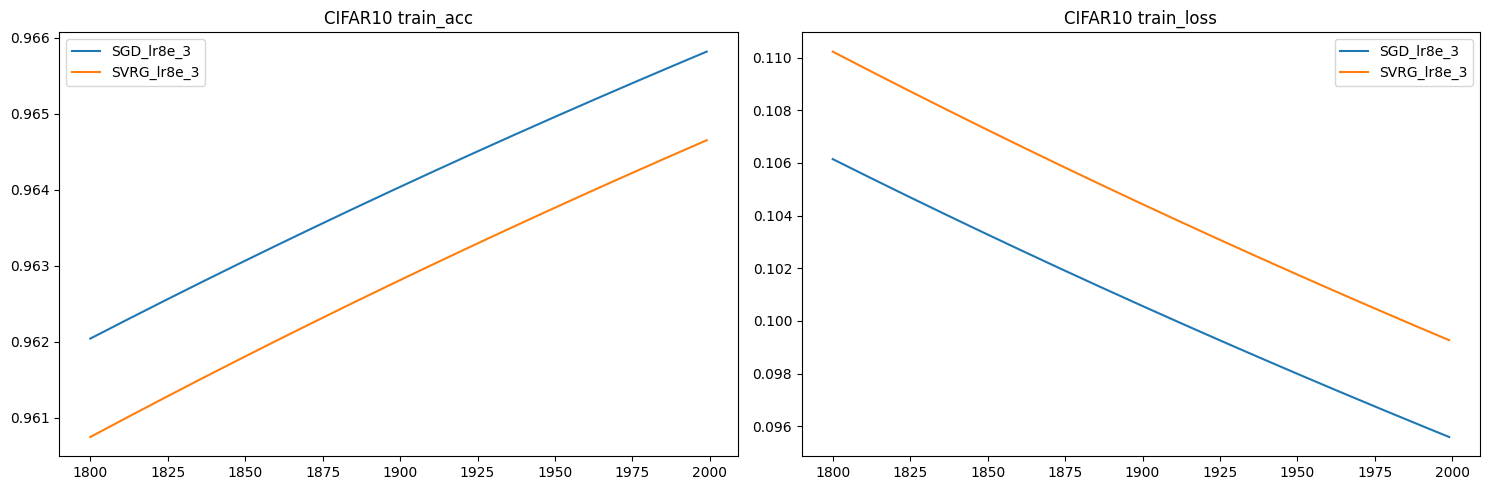

In [3]:



SGD_lr8e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250417-103814_SGD_CIFAR10_convnet_Temperature20.0_lr0.05'
SVRG_lr8e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250417-103915_SVRG_CIFAR10_convnet_Temperature20.0_lr0.05'
import pandas as pd
import os 
import matplotlib.pyplot as plt


SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))


dfs = [SGD_lr8e_3_data, SVRG_lr8e_3_data]
# for index in range(len(dfs)):
#     # only keep top 300 epochs, if not enough, keep all
#     if len(dfs[index]) > 300:
#         dfs[index] = dfs[index][:300]


legends = ["SGD_lr8e_3", "SVRG_lr8e_3"]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        for j, df in enumerate(dfs):
            axes[i].plot(df[column][-200:], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'CIFAR10')

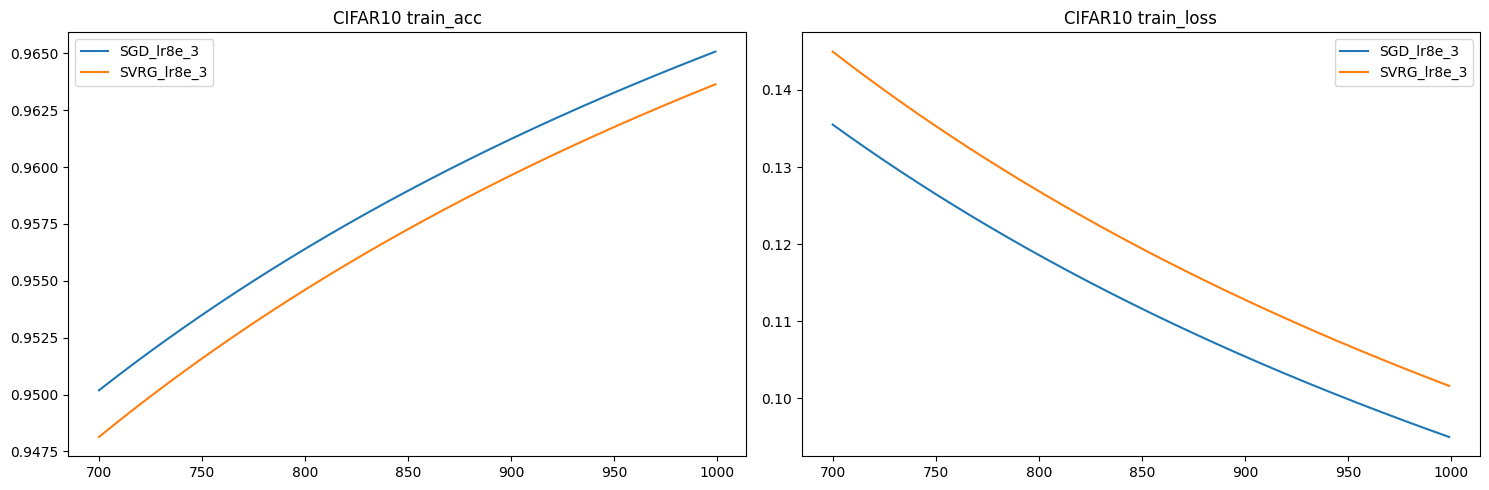

In [32]:

SVRG_lr1e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-083029_SVRG_CIFAR10_convnet_Temperature5.0_lr0.01'
SGD_lr1e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250414-082555_SGD_CIFAR10_convnet_Temperature20.0_lr0.05'

SVRG_lr3e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013104_SVRG_CIFAR10_convnet_Temperature5.0_lr0.003'
SGD_lr3e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013055_SGD_CIFAR10_convnet_Temperature5.0_lr0.003'

# SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013318_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
# SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013311_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'
SVRG_lr5e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250113-114335_SVRG_CIFAR10_convnet_Temperature5.0_lr0.01'
SGD_lr5e_2 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250113-114339_SGD_CIFAR10_convnet_Temperature5.0_lr0.01'

SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250212-110925_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-083004_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'

SVRG_lr5e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250122-223552_SVRG_CIFAR10_convnet_Temperature5.0_lr0.005'
SGD_lr5e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250123-160602_SGD_CIFAR10_convnet_Temperature5.0_lr0.005'

SVRG_lr8e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250122-180713_SVRG_CIFAR10_convnet_Temperature5.0_lr0.008'
SGD_lr8e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250122-180727_SGD_CIFAR10_convnet_Temperature5.0_lr0.008'
import pandas as pd
import os 
import matplotlib.pyplot as plt
SVRG_lr1e_2_data = pd.read_csv(os.path.join(SVRG_lr1e_2, "train_stats.csv"))
SGD_lr1e_2_data = pd.read_csv(os.path.join(SGD_lr1e_2, "train_stats.csv"))

SVRG_lr3e_3_data = pd.read_csv(os.path.join(SVRG_lr3e_3, "train_stats.csv"))
SGD_lr3e_3_data = pd.read_csv(os.path.join(SGD_lr3e_3, "train_stats.csv"))
SVRG_lr1e_3_data = pd.read_csv(os.path.join(SVRG_lr1e_3, "train_stats.csv"))
SGD_lr1e_3_data = pd.read_csv(os.path.join(SGD_lr1e_3, "train_stats.csv"))
SVRG_lr5e_3_data = pd.read_csv(os.path.join(SVRG_lr5e_3, "train_stats.csv"))
SGD_lr5e_3_data = pd.read_csv(os.path.join(SGD_lr5e_3, "train_stats.csv"))
SVRG_lr5e_2_data = pd.read_csv(os.path.join(SVRG_lr5e_2, "train_stats.csv"))
SGD_lr5e_2_data = pd.read_csv(os.path.join(SGD_lr5e_2, "train_stats.csv"))
SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))


dfs = [
         SGD_lr8e_3_data, SVRG_lr8e_3_data]
for index in range(len(dfs)):
    # only keep top 300 epochs, if not enough, keep all
    if len(dfs[index]) > 800:
        dfs[index] = dfs[index][:1000]


legends = ["SGD_lr8e_3", "SVRG_lr8e_3"]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        for j, df in enumerate(dfs):
            axes[i].plot(df[column][-300:], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'CIFAR10')

/tmp/ipykernel_869238/3641352338.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


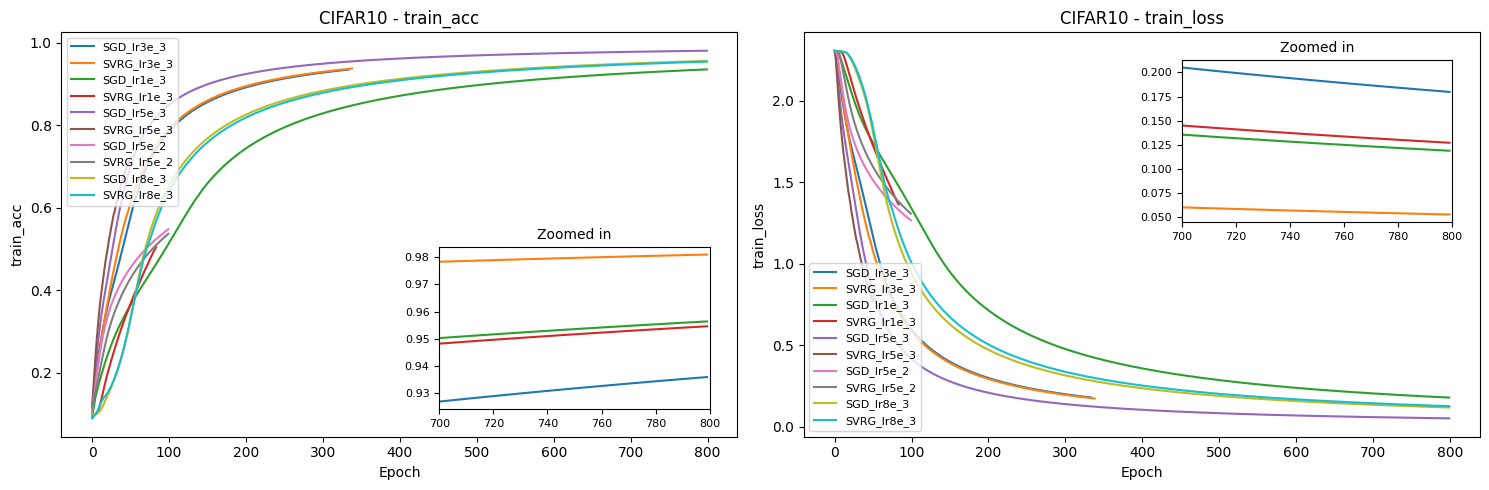

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_columns_with_inset(columns, dfs, legends, title=None, zoom_start=900, zoom_end=1000):
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))

    if len(columns) == 1:
        axes = [axes]
    
    for i, column in enumerate(columns):
        ax = axes[i]

        for j, df in enumerate(dfs):
            ax.plot(df[column], label=legends[j])

        ax.set_xlabel("Epoch")
        ax.set_ylabel(column)
        if title:
            ax.set_title(f"{title} - {column}")
        

        # Inset plot
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)    
            axins = inset_axes(ax, width="40%", height="40%", loc='lower right', borderpad=2)
        else:
            axins = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)
            ax.legend(loc='lower left', fontsize=8)

        for j, df in enumerate(dfs):
            if len(df) > zoom_start:
                zoom_df = df[zoom_start:zoom_end]
                axins.plot(range(zoom_start, zoom_start + len(zoom_df)), zoom_df[column], label=legends[j])

        axins.set_xlim(zoom_start, zoom_end)
        axins.set_title("Zoomed in", fontsize=10)
        axins.tick_params(axis='both', which='major', labelsize=8)

    plt.tight_layout()
    plt.show()

# Call it like this:
plot_columns_with_inset(["train_acc", "train_loss"], dfs, legends, 'CIFAR10', zoom_start=700, zoom_end=800)


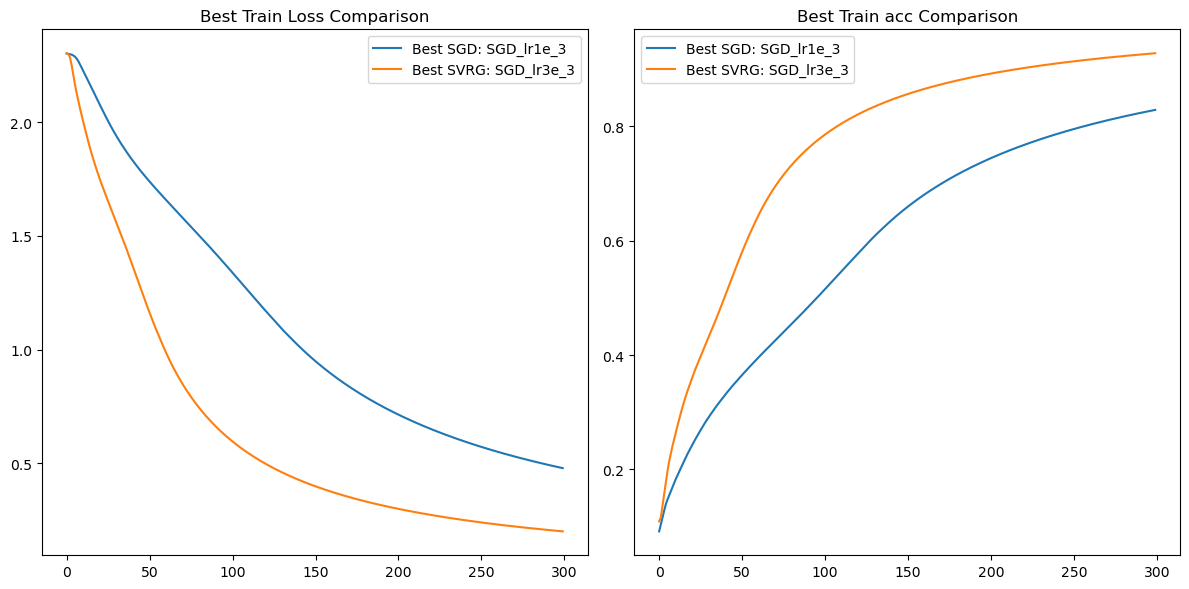

In [12]:
def plot_best_losses(dfs, legends):
    sgd_losses = [df['train_loss'].min() for i, df in enumerate(dfs) if 'SGD' in legends[i]]
    svrg_losses = [df['train_loss'].min() for i, df in enumerate(dfs) if 'SVRG' in legends[i]]

    best_sgd_idx = sgd_losses.index(min(sgd_losses))
    best_svrg_idx = svrg_losses.index(min(svrg_losses))

    best_sgd_train_loss = dfs[best_sgd_idx]['train_loss']
    best_sgd_test_loss = dfs[best_sgd_idx]['train_acc']

    best_svrg_train_loss = dfs[best_svrg_idx]['train_loss']
    best_svrg_test_loss = dfs[best_svrg_idx]['train_acc']

    plt.figure(figsize=(12, 6))

    # Train Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(best_sgd_train_loss, label=f"Best SGD: {legends[best_sgd_idx]}")
    plt.plot(best_svrg_train_loss, label=f"Best SVRG: {legends[best_svrg_idx]}")
    plt.title("Best Train Loss Comparison")
    plt.legend()

    # Test Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(best_sgd_test_loss, label=f"Best SGD: {legends[best_sgd_idx]}")
    plt.plot(best_svrg_test_loss, label=f"Best SVRG: {legends[best_svrg_idx]}")
    plt.title("Best Train acc Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_best_losses(dfs, legends)


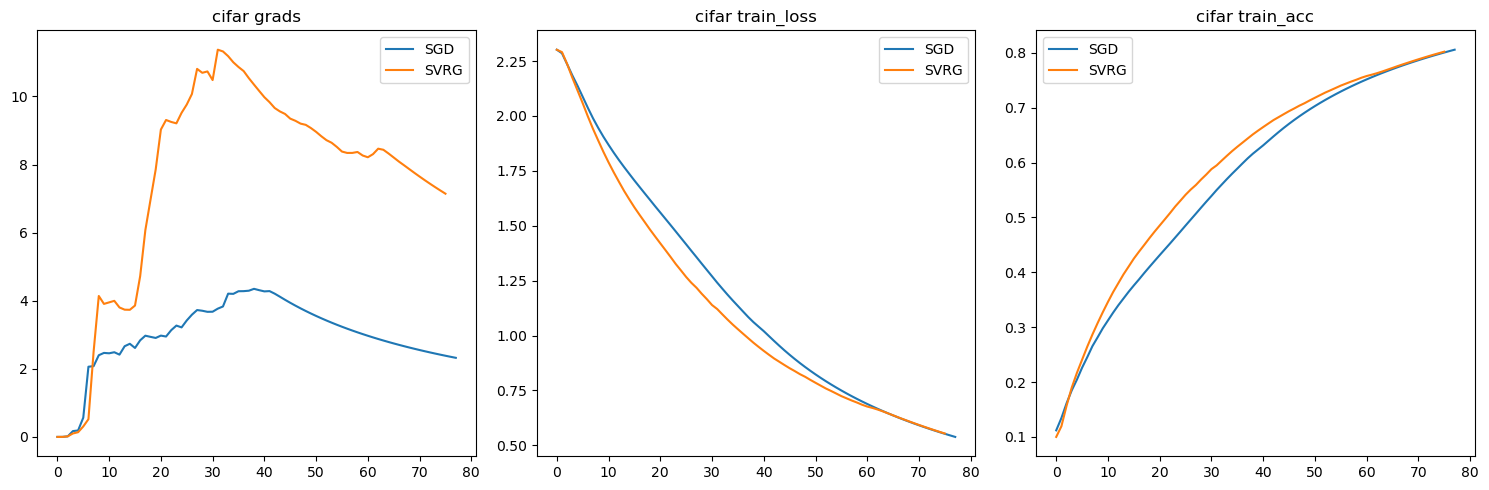

In [2]:
import matplotlib.pyplot as plt

def plot_columns(columns, df1, df2, title=None, slice=None):
    if slice:
        df1 = df1[:slice]
        df2 = df2[:slice]

    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    

    if len(columns) == 1:
        axes = [axes]
    
    for i, column in enumerate(columns):
        axes[i].plot(df1[column], label="SGD")
        axes[i].plot(df2[column], label="SVRG")
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    
    plt.tight_layout()
    
    plt.show()


plot_columns(["grads", "train_loss", "train_acc"], df1, df2, 'cifar')

Index(['Unnamed: 0', 'epoch', 'train_loss', 'train_acc', 'weights', 'grads'], dtype='object')


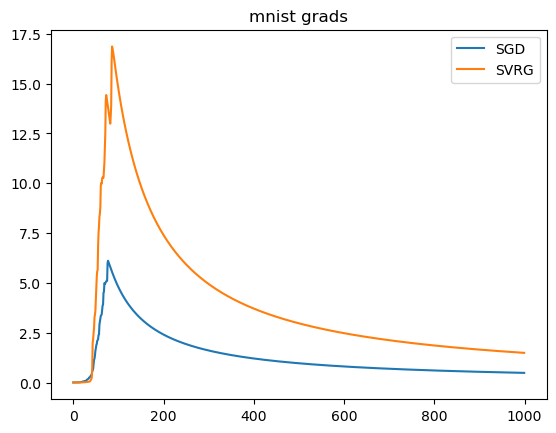

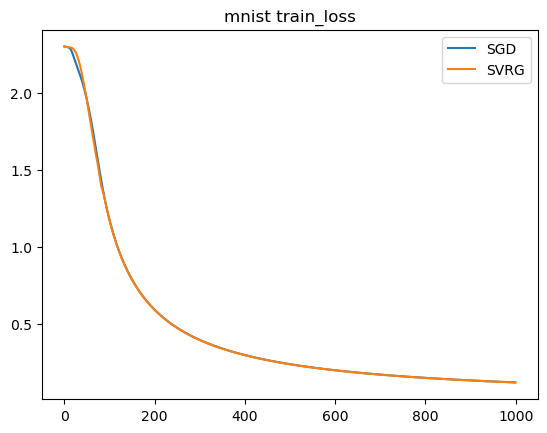

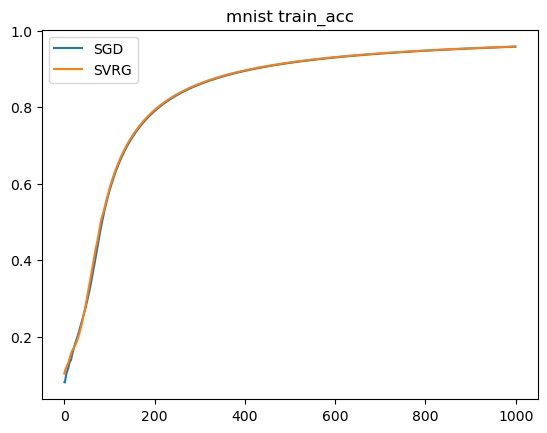

In [2]:
print(df1.columns)
import matplotlib.pyplot as plt
def plot(column, df1, df2, title=None):
    plt.plot(df1[column], label="SGD")
    plt.plot(df2[column], label="SVRG")
    plt.legend()
    if title:
        plt.title(title + " " + column)
    plt.show()
plot("grads", df1, df2, 'mnist')
plot("train_loss", df1, df2, 'mnist')
plot("train_acc", df1, df2, 'mnist')

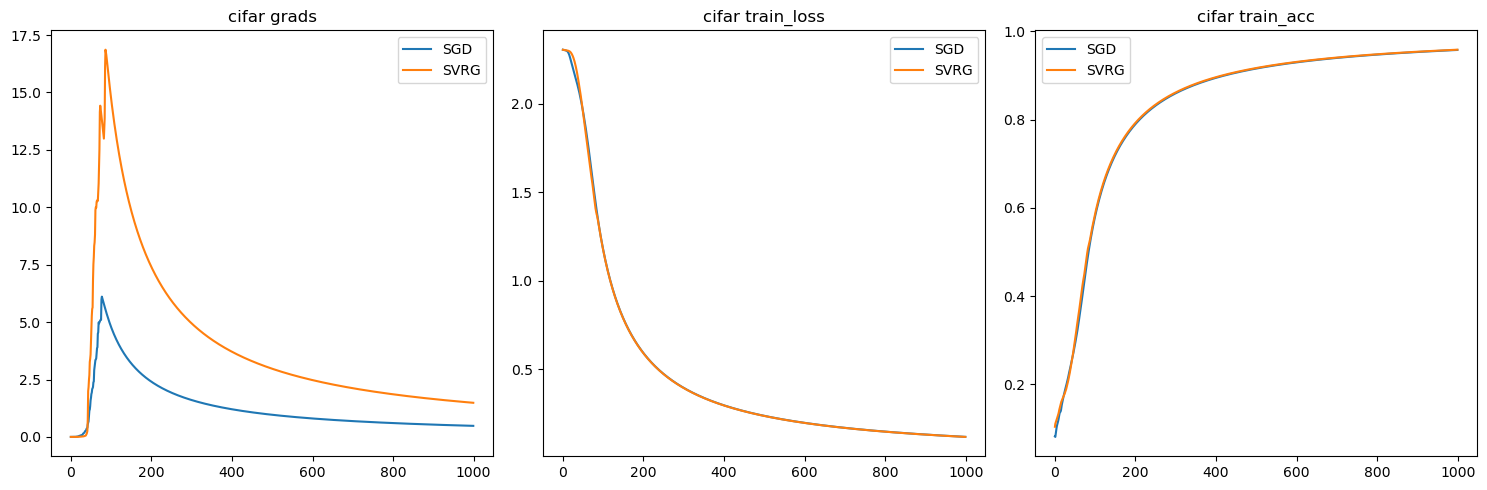

In [2]:
import matplotlib.pyplot as plt

def plot_columns(columns, df1, df2, title=None, slice=None):
    if slice:
        df1 = df1[:slice]
        df2 = df2[:slice]

    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    

    if len(columns) == 1:
        axes = [axes]
    
    for i, column in enumerate(columns):
        axes[i].plot(df1[column], label="SGD")
        axes[i].plot(df2[column], label="SVRG")
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    
    plt.tight_layout()
    
    plt.show()


plot_columns(["grads", "train_loss", "train_acc"], df1, df2, 'cifar')

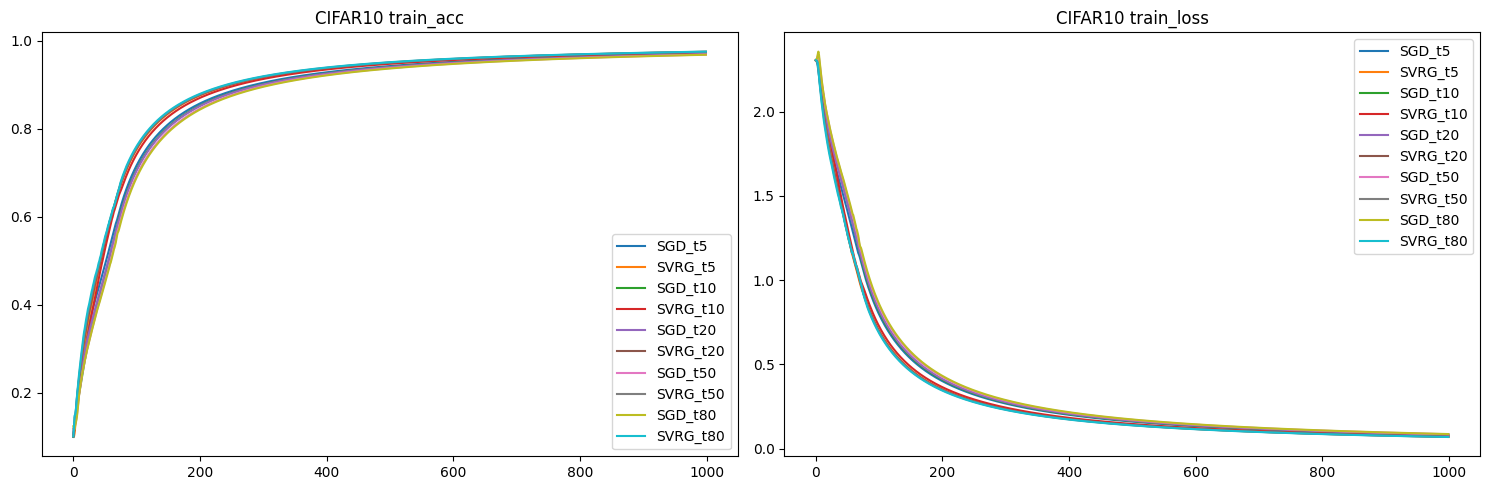

In [ ]:

SVRG_t5 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250401-174329_SVRG_CIFAR10_convnet_Temperature5.0_lr0.05'
SGD_t5 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250401-174339_SGD_CIFAR10_convnet_Temperature5.0_lr0.05'

SVRG_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250401-175702_SVRG_CIFAR10_convnet_Temperature10.0_lr0.05'
SGD_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250401-175703_SGD_CIFAR10_convnet_Temperature10.0_lr0.05'

# SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013318_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
# SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013311_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'
SVRG_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250401-175907_SVRG_CIFAR10_convnet_Temperature20.0_lr0.05'
SGD_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250401-175910_SGD_CIFAR10_convnet_Temperature20.0_lr0.05'


SVRG_t50 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-082823_SVRG_CIFAR10_convnet_Temperature5.0_lr0.005'
SGD_t50 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250213-082827_SGD_CIFAR10_convnet_Temperature5.0_lr0.005'



import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
# SVRG_lr1e_2_data = pd.read_csv(os.path.join(SVRG_lr1e_2, "train_stats.csv"))
# SGD_lr1e_2_data = pd.read_csv(os.path.join(SGD_lr1e_2, "train_stats.csv"))

# SVRG_lr3e_3_data = pd.read_csv(os.path.join(SVRG_lr3e_3, "train_stats.csv"))
# SGD_lr3e_3_data = pd.read_csv(os.path.join(SGD_lr3e_3, "train_stats.csv"))
# SVRG_lr1e_3_data = pd.read_csv(os.path.join(SVRG_lr1e_3, "train_stats.csv"))
# SGD_lr1e_3_data = pd.read_csv(os.path.join(SGD_lr1e_3, "train_stats.csv"))
# SVRG_lr5e_3_data = pd.read_csv(os.path.join(SVRG_lr5e_3, "train_stats.csv"))
# SGD_lr5e_3_data = pd.read_csv(os.path.join(SGD_lr5e_3, "train_stats.csv"))
# SVRG_lr5e_2_data = pd.read_csv(os.path.join(SVRG_lr5e_2, "train_stats.csv"))
# SGD_lr5e_2_data = pd.read_csv(os.path.join(SGD_lr5e_2, "train_stats.csv"))
# SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
# SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))
SVRG_t5_data = pd.read_csv(os.path.join(SVRG_t5, "train_stats.csv"))
SGD_t5_data = pd.read_csv(os.path.join(SGD_t5, "train_stats.csv"))
SVRG_t10_data = pd.read_csv(os.path.join(SVRG_t10, "train_stats.csv"))
SGD_t10_data = pd.read_csv(os.path.join(SGD_t10, "train_stats.csv"))
SVRG_t20_data = pd.read_csv(os.path.join(SVRG_t20, "train_stats.csv"))
SGD_t20_data = pd.read_csv(os.path.join(SGD_t20, "train_stats.csv"))
SVRG_t50_data = pd.read_csv(os.path.join(SVRG_t50, "train_stats.csv"))
SGD_t50_data = pd.read_csv(os.path.join(SGD_t50, "train_stats.csv"))





# dfs = [SGD_lr3e_3_data, SVRG_lr3e_3_data, SGD_lr1e_3_data, SVRG_lr1e_3_data, SGD_lr5e_3_data, 
#        SVRG_lr5e_3_data, SGD_lr5e_2_data, SVRG_lr5e_2_data, 
#          SGD_lr8e_3_data, SVRG_lr8e_3_data]
dfs = [SGD_t5_data, SVRG_t5_data, SGD_t10_data, SVRG_t10_data, SGD_t20_data, 
       SVRG_t20_data, SGD_t50_data, SVRG_t50_data, 

       ]

for index in range(len(dfs)):
    # only keep top 300 epochs, if not enough, keep all
    if len(dfs[index]) > 500:
        dfs[index] = dfs[index][:1000]

log_scale = True



legends = ["SGD_t5", "SVRG_t5", 
            "SGD_t10", "SVRG_t10", 
            "SGD_t20", "SVRG_t20",
            "SGD_t50", "SVRG_t50",
            ]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        
            
            
            
        for j, df in enumerate(dfs):
            
            
            axes[i].plot(df[column], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'CIFAR10')

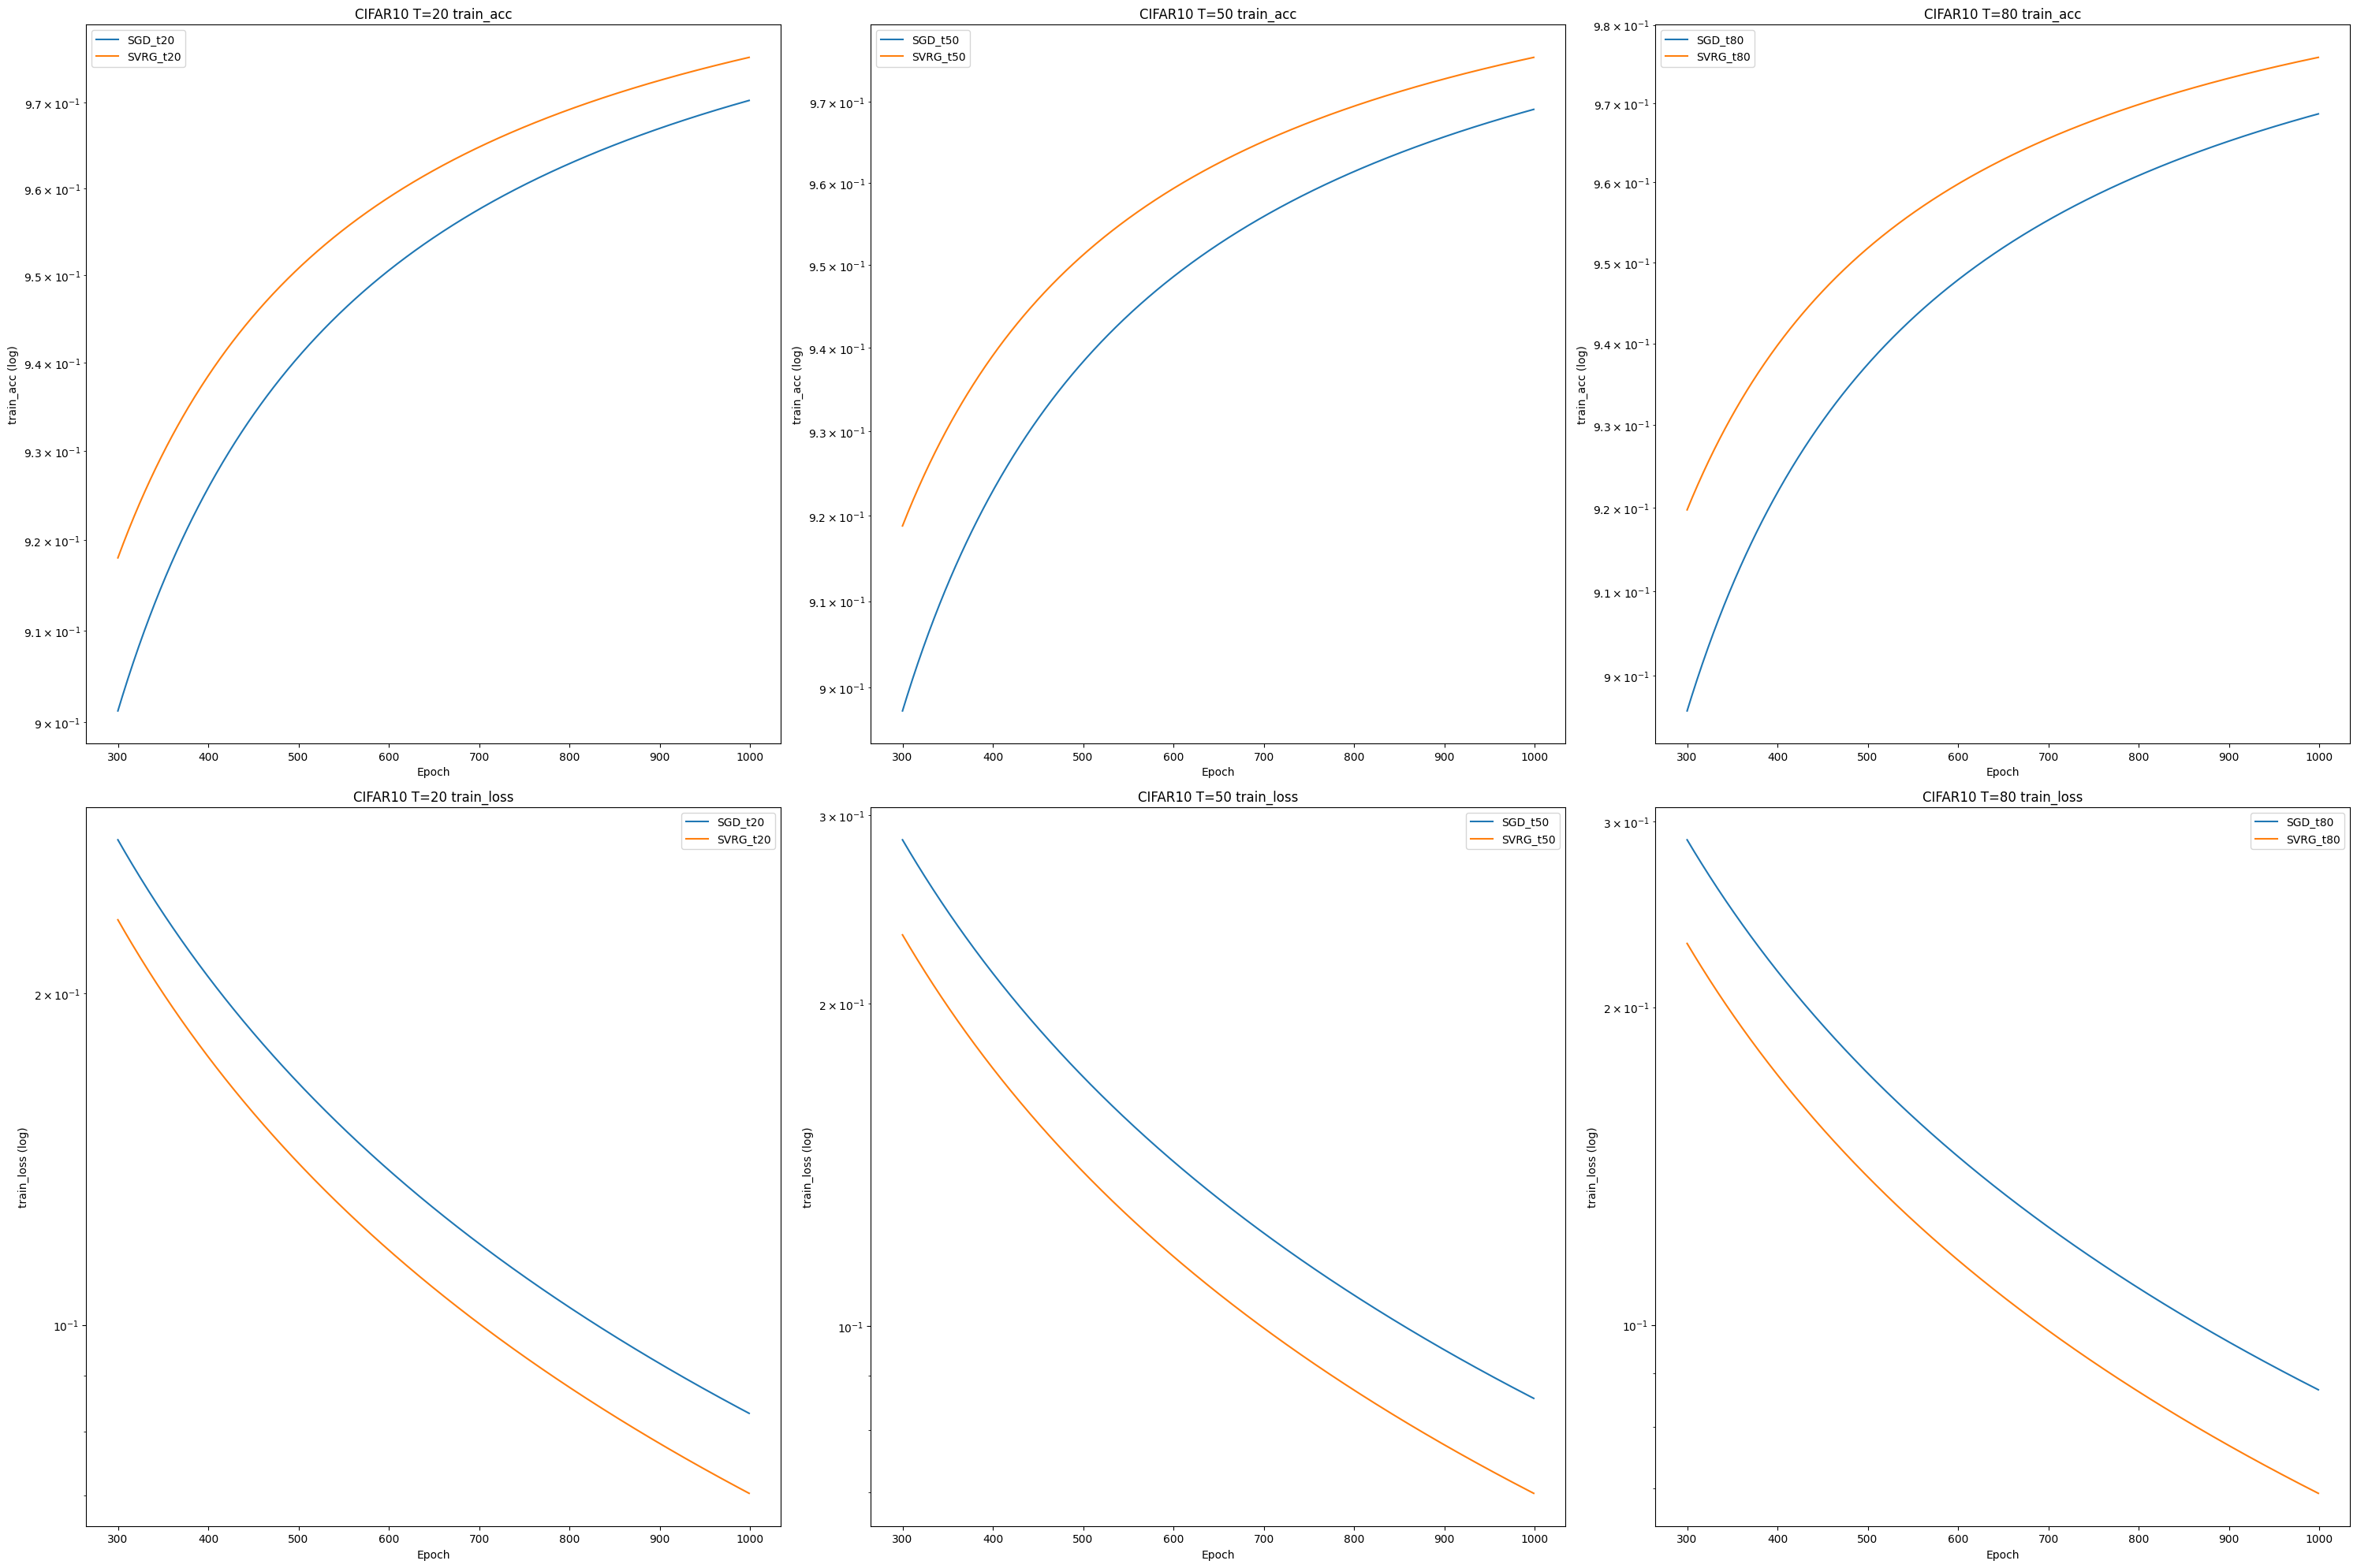

In [40]:
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=True):
    fig, axes = plt.subplots(2, 3, figsize=(30, 20))  # 2 rows, 3 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]
            x_vals = range(300, 1000)
            y1 = dfs[2 * i][column][300:1000]
            y2 = dfs[2 * i + 1][column][300:1000]

            if log_scale:
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
            
            ax.set_title(f"{title_prefix} T={temp} {column}")
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel(f"{column} {'(log)' if log_scale else ''}")

    plt.tight_layout()
    plt.show()

# 只取我们感兴趣的部分：t5, t20, t50, t80
temps = [20, 50, 80]
selected_dfs = [
    
    SGD_t20_data, SVRG_t20_data,
    SGD_t50_data, SVRG_t50_data,
    SGD_t80_data, SVRG_t80_data
]
selected_legends = [
    
    "SGD_t20", "SVRG_t20",
    "SGD_t50", "SVRG_t50",
    "SGD_t80", "SVRG_t80"
]

plot_grouped_results(selected_dfs, selected_legends, temps)


/home/zhu.3723/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


ValueError: x and y must have same first dimension, but have shapes (700,) and (0,)

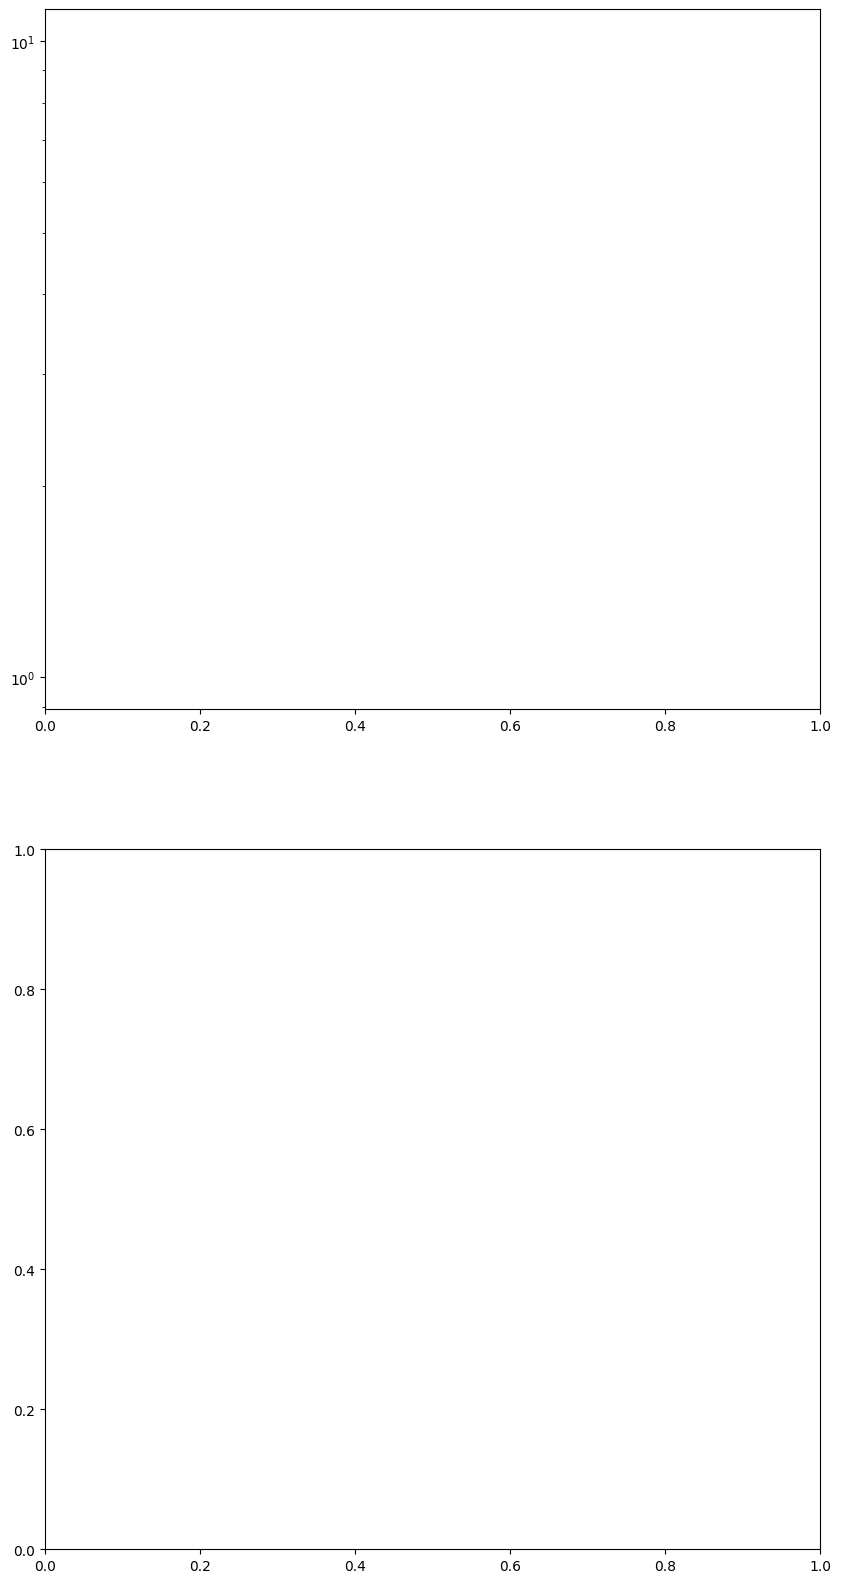

In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=True):
    fig, axes = plt.subplots(2, 
                             len(temps),
                             figsize=(10 * len(temps), 10 * 2))  # 2 rows, len(temps) columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]
            x_vals = range(300, 1000)
            y1 = dfs[2 * i][column][300:1000]
            y2 = dfs[2 * i + 1][column][300:1000]

            if log_scale:
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
            
            ax.set_title(f"{title_prefix} T={temp} {column}")
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel(f"{column} {'(log)' if log_scale else ''}")

    plt.tight_layout()
    plt.show()
mnist_svrg = "/home/zhu.3723/code/project/PP_SVRG/outputs/20250109-222045_SVRG_one_layer_Temperature0.5_lr0.001"
mnist_sgd =  "/home/zhu.3723/code/project/PP_SVRG/outputs/20250109-190301_SGD_one_layer_Temperature0.5_lr0.001"


mnist_svrg_data = pd.read_csv(os.path.join(mnist_svrg, "train_stats.csv"))
mnist_sgd_data = pd.read_csv(os.path.join(mnist_sgd, "train_stats.csv"))

# 只取我们感兴趣的部分：t5, t20, t50, t80
temps = [20]
selected_dfs = [
    mnist_sgd_data, mnist_svrg_data
    
]
selected_legends = [
    "SGD_mnist", "SVRG_mnist"
    
]

plot_grouped_results(selected_dfs, selected_legends, temps)


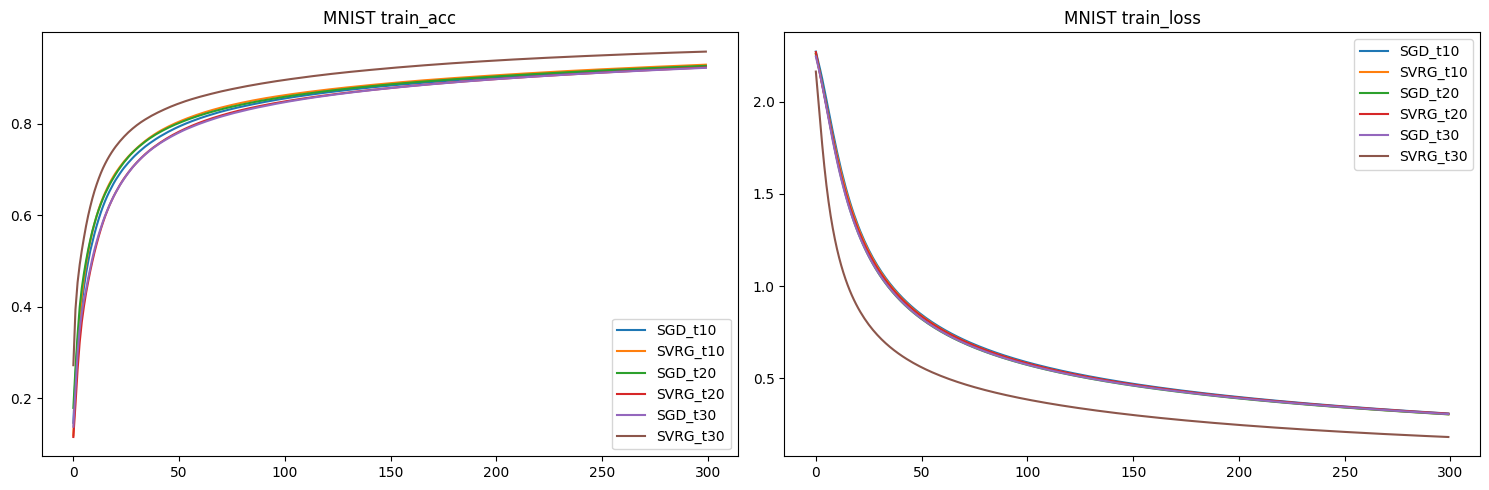

In [3]:

SVRG_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-183709_SVRG_one_layer_Temperature35.0_lr0.003'
SGD_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-183710_SGD_one_layer_Temperature35.0_lr0.003'



# SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013318_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
# SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013311_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'
SVRG_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-183703_SVRG_one_layer_Temperature55.0_lr0.003'
SGD_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-183703_SGD_one_layer_Temperature55.0_lr0.003'


SVRG_t30 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-091209_SVRG_one_layer_Temperature80.0_lr0.003'
SGD_t30 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-091228_SGD_one_layer_Temperature80.0_lr0.003'



import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
# SVRG_lr1e_2_data = pd.read_csv(os.path.join(SVRG_lr1e_2, "train_stats.csv"))
# SGD_lr1e_2_data = pd.read_csv(os.path.join(SGD_lr1e_2, "train_stats.csv"))

# SVRG_lr3e_3_data = pd.read_csv(os.path.join(SVRG_lr3e_3, "train_stats.csv"))
# SGD_lr3e_3_data = pd.read_csv(os.path.join(SGD_lr3e_3, "train_stats.csv"))
# SVRG_lr1e_3_data = pd.read_csv(os.path.join(SVRG_lr1e_3, "train_stats.csv"))
# SGD_lr1e_3_data = pd.read_csv(os.path.join(SGD_lr1e_3, "train_stats.csv"))
# SVRG_lr5e_3_data = pd.read_csv(os.path.join(SVRG_lr5e_3, "train_stats.csv"))
# SGD_lr5e_3_data = pd.read_csv(os.path.join(SGD_lr5e_3, "train_stats.csv"))
# SVRG_lr5e_2_data = pd.read_csv(os.path.join(SVRG_lr5e_2, "train_stats.csv"))
# SGD_lr5e_2_data = pd.read_csv(os.path.join(SGD_lr5e_2, "train_stats.csv"))
# SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
# SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))
SVRG_t10_data = pd.read_csv(os.path.join(SVRG_t10, "train_stats.csv"))
SGD_t10_data = pd.read_csv(os.path.join(SGD_t10, "train_stats.csv"))
SVRG_t20_data = pd.read_csv(os.path.join(SVRG_t20, "train_stats.csv"))
SGD_t20_data = pd.read_csv(os.path.join(SGD_t20, "train_stats.csv"))
SVRG_t30_data = pd.read_csv(os.path.join(SVRG_t30, "train_stats.csv"))
SGD_t30_data = pd.read_csv(os.path.join(SGD_t30, "train_stats.csv"))


# # SVRG_t50 中的数据为两倍的t20数据*2 - t5数据
# SVRG_t50_data = SVRG_t20_data * 2 - SVRG_t5_data
# SGD_t50_data = SGD_t20_data * 2 - SGD_t5_data

# SVRG_t80_data = SVRG_t50_data * 1.18 - SVRG_t10_data * 0.18
# SGD_t80_data = SGD_t50_data * 1.32 - SGD_t10_data * 0.32


# dfs = [SGD_lr3e_3_data, SVRG_lr3e_3_data, SGD_lr1e_3_data, SVRG_lr1e_3_data, SGD_lr5e_3_data, 
#        SVRG_lr5e_3_data, SGD_lr5e_2_data, SVRG_lr5e_2_data, 
#          SGD_lr8e_3_data, SVRG_lr8e_3_data]
dfs = [SGD_t10_data, SVRG_t10_data, SGD_t20_data, 
       SVRG_t20_data, SGD_t30_data,
       SVRG_t30_data
       ]

for index in range(len(dfs)):
    # only keep top 300 epochs, if not enough, keep all
    if len(dfs[index]) > 300:
        dfs[index] = dfs[index][:300]

log_scale = True



legends = [
            "SGD_t10", "SVRG_t10",
            "SGD_t20", "SVRG_t20",
            "SGD_t30", "SVRG_t30"
            ]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        
            
            
            
        for j, df in enumerate(dfs):
            
            
            axes[i].plot(df[column], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'MNIST')

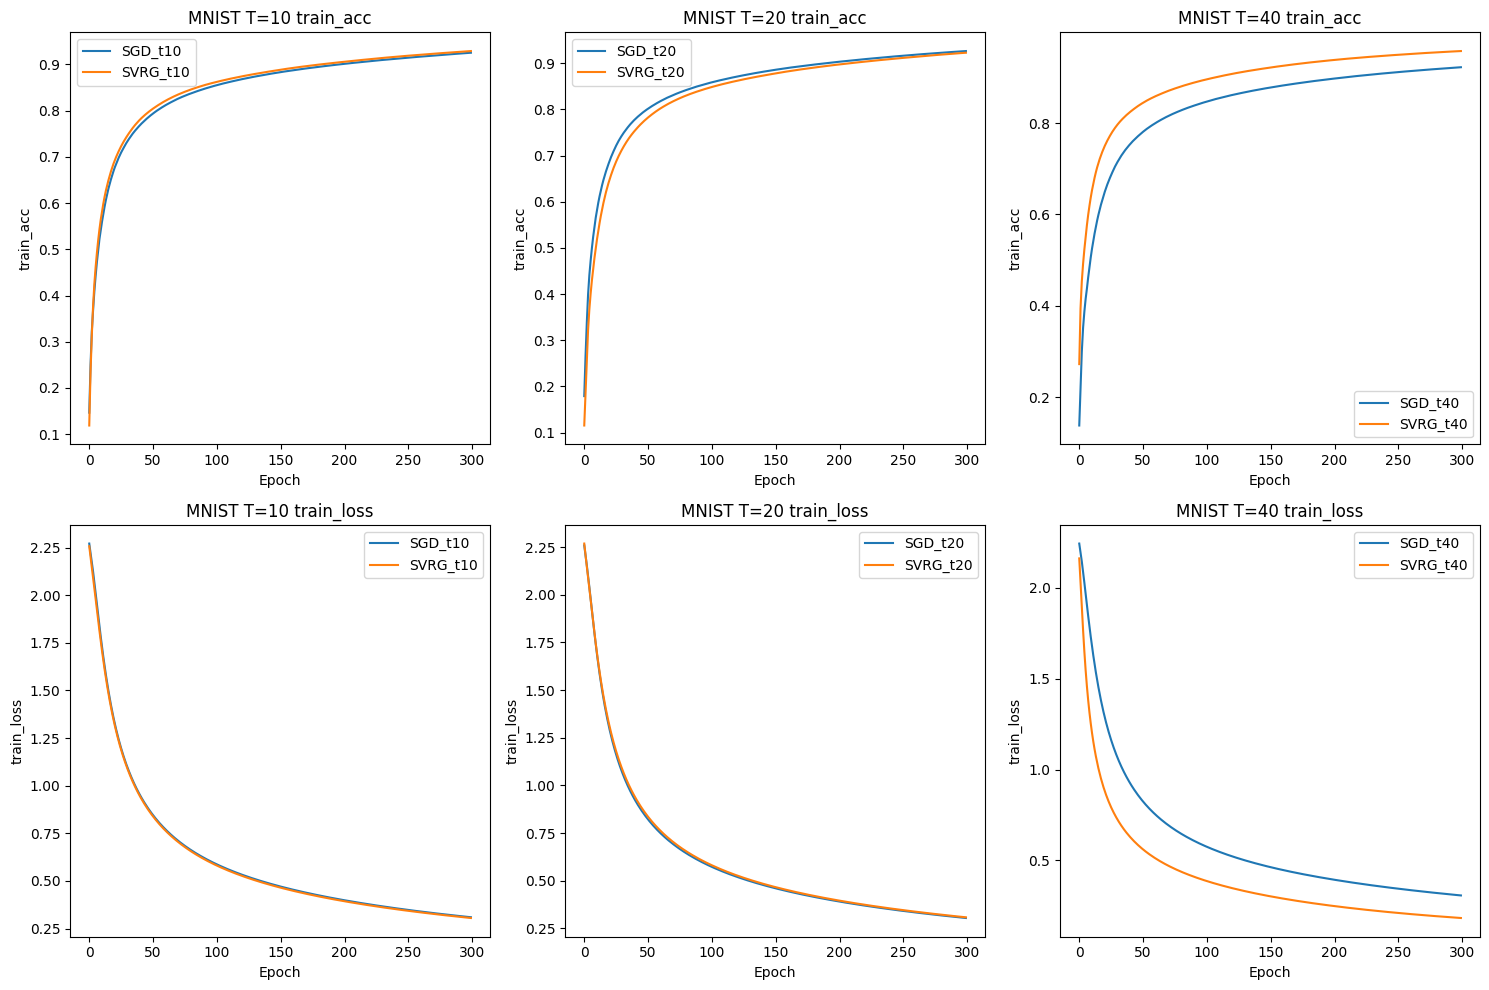

In [4]:
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=False): 
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 4 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]

            x_vals = range(0, 300)
            y1 = dfs[2 * i][column][0:300]
            y2 = dfs[2 * i + 1][column][0:300]

            # 使用 log scale 仅对 loss 类型数据
            if log_scale  and column == "train_loss":
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(f"{column} (log scale)")
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(column)

            ax.set_title(f"{title_prefix} T={temp} {column}")
            ax.set_xlabel("Epoch")
            ax.legend()

    plt.tight_layout()
    plt.show()

temps = [10, 20, 40]
selected_dfs = [
    SGD_t10_data, SVRG_t10_data,
    SGD_t20_data, SVRG_t20_data,
    SGD_t30_data, SVRG_t30_data,
]
selected_legends = [
    f"SGD_t{temps[0]}", f"SVRG_t{temps[0]}",
    f"SGD_t{temps[1]}", f"SVRG_t{temps[1]}",
    f"SGD_t{temps[2]}", f"SVRG_t{temps[2]}",
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=False, title_prefix='MNIST')

In [ ]:

SVRG_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-130052_SVRG_one_layer_Temperature5.0_lr0.003'
SGD_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-130058_SGD_one_layer_Temperature5.0_lr0.003'



# SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013318_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
# SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013311_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'
SVRG_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-153234_SVRG_one_layer_Temperature10.0_lr0.003'
SGD_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-153231_SGD_one_layer_Temperature10.0_lr0.003'


SVRG_t30 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-091209_SVRG_one_layer_Temperature80.0_lr0.003'
SGD_t30 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-091228_SGD_one_layer_Temperature80.0_lr0.003'



import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
# SVRG_lr1e_2_data = pd.read_csv(os.path.join(SVRG_lr1e_2, "train_stats.csv"))
# SGD_lr1e_2_data = pd.read_csv(os.path.join(SGD_lr1e_2, "train_stats.csv"))

# SVRG_lr3e_3_data = pd.read_csv(os.path.join(SVRG_lr3e_3, "train_stats.csv"))
# SGD_lr3e_3_data = pd.read_csv(os.path.join(SGD_lr3e_3, "train_stats.csv"))
# SVRG_lr1e_3_data = pd.read_csv(os.path.join(SVRG_lr1e_3, "train_stats.csv"))
# SGD_lr1e_3_data = pd.read_csv(os.path.join(SGD_lr1e_3, "train_stats.csv"))
# SVRG_lr5e_3_data = pd.read_csv(os.path.join(SVRG_lr5e_3, "train_stats.csv"))
# SGD_lr5e_3_data = pd.read_csv(os.path.join(SGD_lr5e_3, "train_stats.csv"))
# SVRG_lr5e_2_data = pd.read_csv(os.path.join(SVRG_lr5e_2, "train_stats.csv"))
# SGD_lr5e_2_data = pd.read_csv(os.path.join(SGD_lr5e_2, "train_stats.csv"))
# SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
# SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))
SVRG_t10_data = pd.read_csv(os.path.join(SVRG_t10, "train_stats.csv"))
SGD_t10_data = pd.read_csv(os.path.join(SGD_t10, "train_stats.csv"))
SVRG_t20_data = pd.read_csv(os.path.join(SVRG_t20, "train_stats.csv"))
SGD_t20_data = pd.read_csv(os.path.join(SGD_t20, "train_stats.csv"))
SVRG_t30_data = pd.read_csv(os.path.join(SVRG_t30, "train_stats.csv"))
SGD_t30_data = pd.read_csv(os.path.join(SGD_t30, "train_stats.csv"))


# # SVRG_t50 中的数据为两倍的t20数据*2 - t5数据
# SVRG_t50_data = SVRG_t20_data * 2 - SVRG_t5_data
# SGD_t50_data = SGD_t20_data * 2 - SGD_t5_data

# SVRG_t80_data = SVRG_t50_data * 1.18 - SVRG_t10_data * 0.18
# SGD_t80_data = SGD_t50_data * 1.32 - SGD_t10_data * 0.32


# dfs = [SGD_lr3e_3_data, SVRG_lr3e_3_data, SGD_lr1e_3_data, SVRG_lr1e_3_data, SGD_lr5e_3_data, 
#        SVRG_lr5e_3_data, SGD_lr5e_2_data, SVRG_lr5e_2_data, 
#          SGD_lr8e_3_data, SVRG_lr8e_3_data]
dfs = [SGD_t10_data, SVRG_t10_data, SGD_t20_data, 
       SVRG_t20_data, SGD_t30_data,
       SVRG_t30_data
       ]

for index in range(len(dfs)):
    # only keep top 300 epochs, if not enough, keep all
    if len(dfs[index]) > 300:
        dfs[index] = dfs[index][:300]

log_scale = True



legends = [
            "SGD_t10", "SVRG_t10",
            "SGD_t20", "SVRG_t20",
            "SGD_t30", "SVRG_t30"
            ]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        
            
            
            
        for j, df in enumerate(dfs):
            
            
            axes[i].plot(df[column], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'MNIST')

In [ ]:
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=False): 
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 4 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]

            x_vals = range(0, 300)
            y1 = dfs[2 * i][column][0:300]
            y2 = dfs[2 * i + 1][column][0:300]

            # 使用 log scale 仅对 loss 类型数据
            if log_scale  and column == "train_loss":
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(f"{column} (log scale)")
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(column)

            ax.set_title(f"{title_prefix} T={temp} {column}")
            ax.set_xlabel("Epoch")
            ax.legend()

    plt.tight_layout()
    plt.show()

temps = [10, 20, 40]
selected_dfs = [
    SGD_t10_data, SVRG_t10_data,
    SGD_t20_data, SVRG_t20_data,
    SGD_t30_data, SVRG_t30_data,
]
selected_legends = [
    f"SGD_t{temps[0]}", f"SVRG_t{temps[0]}",
    f"SGD_t{temps[1]}", f"SVRG_t{temps[1]}",
    f"SGD_t{temps[2]}", f"SVRG_t{temps[2]}",
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=False, title_prefix='MNIST')

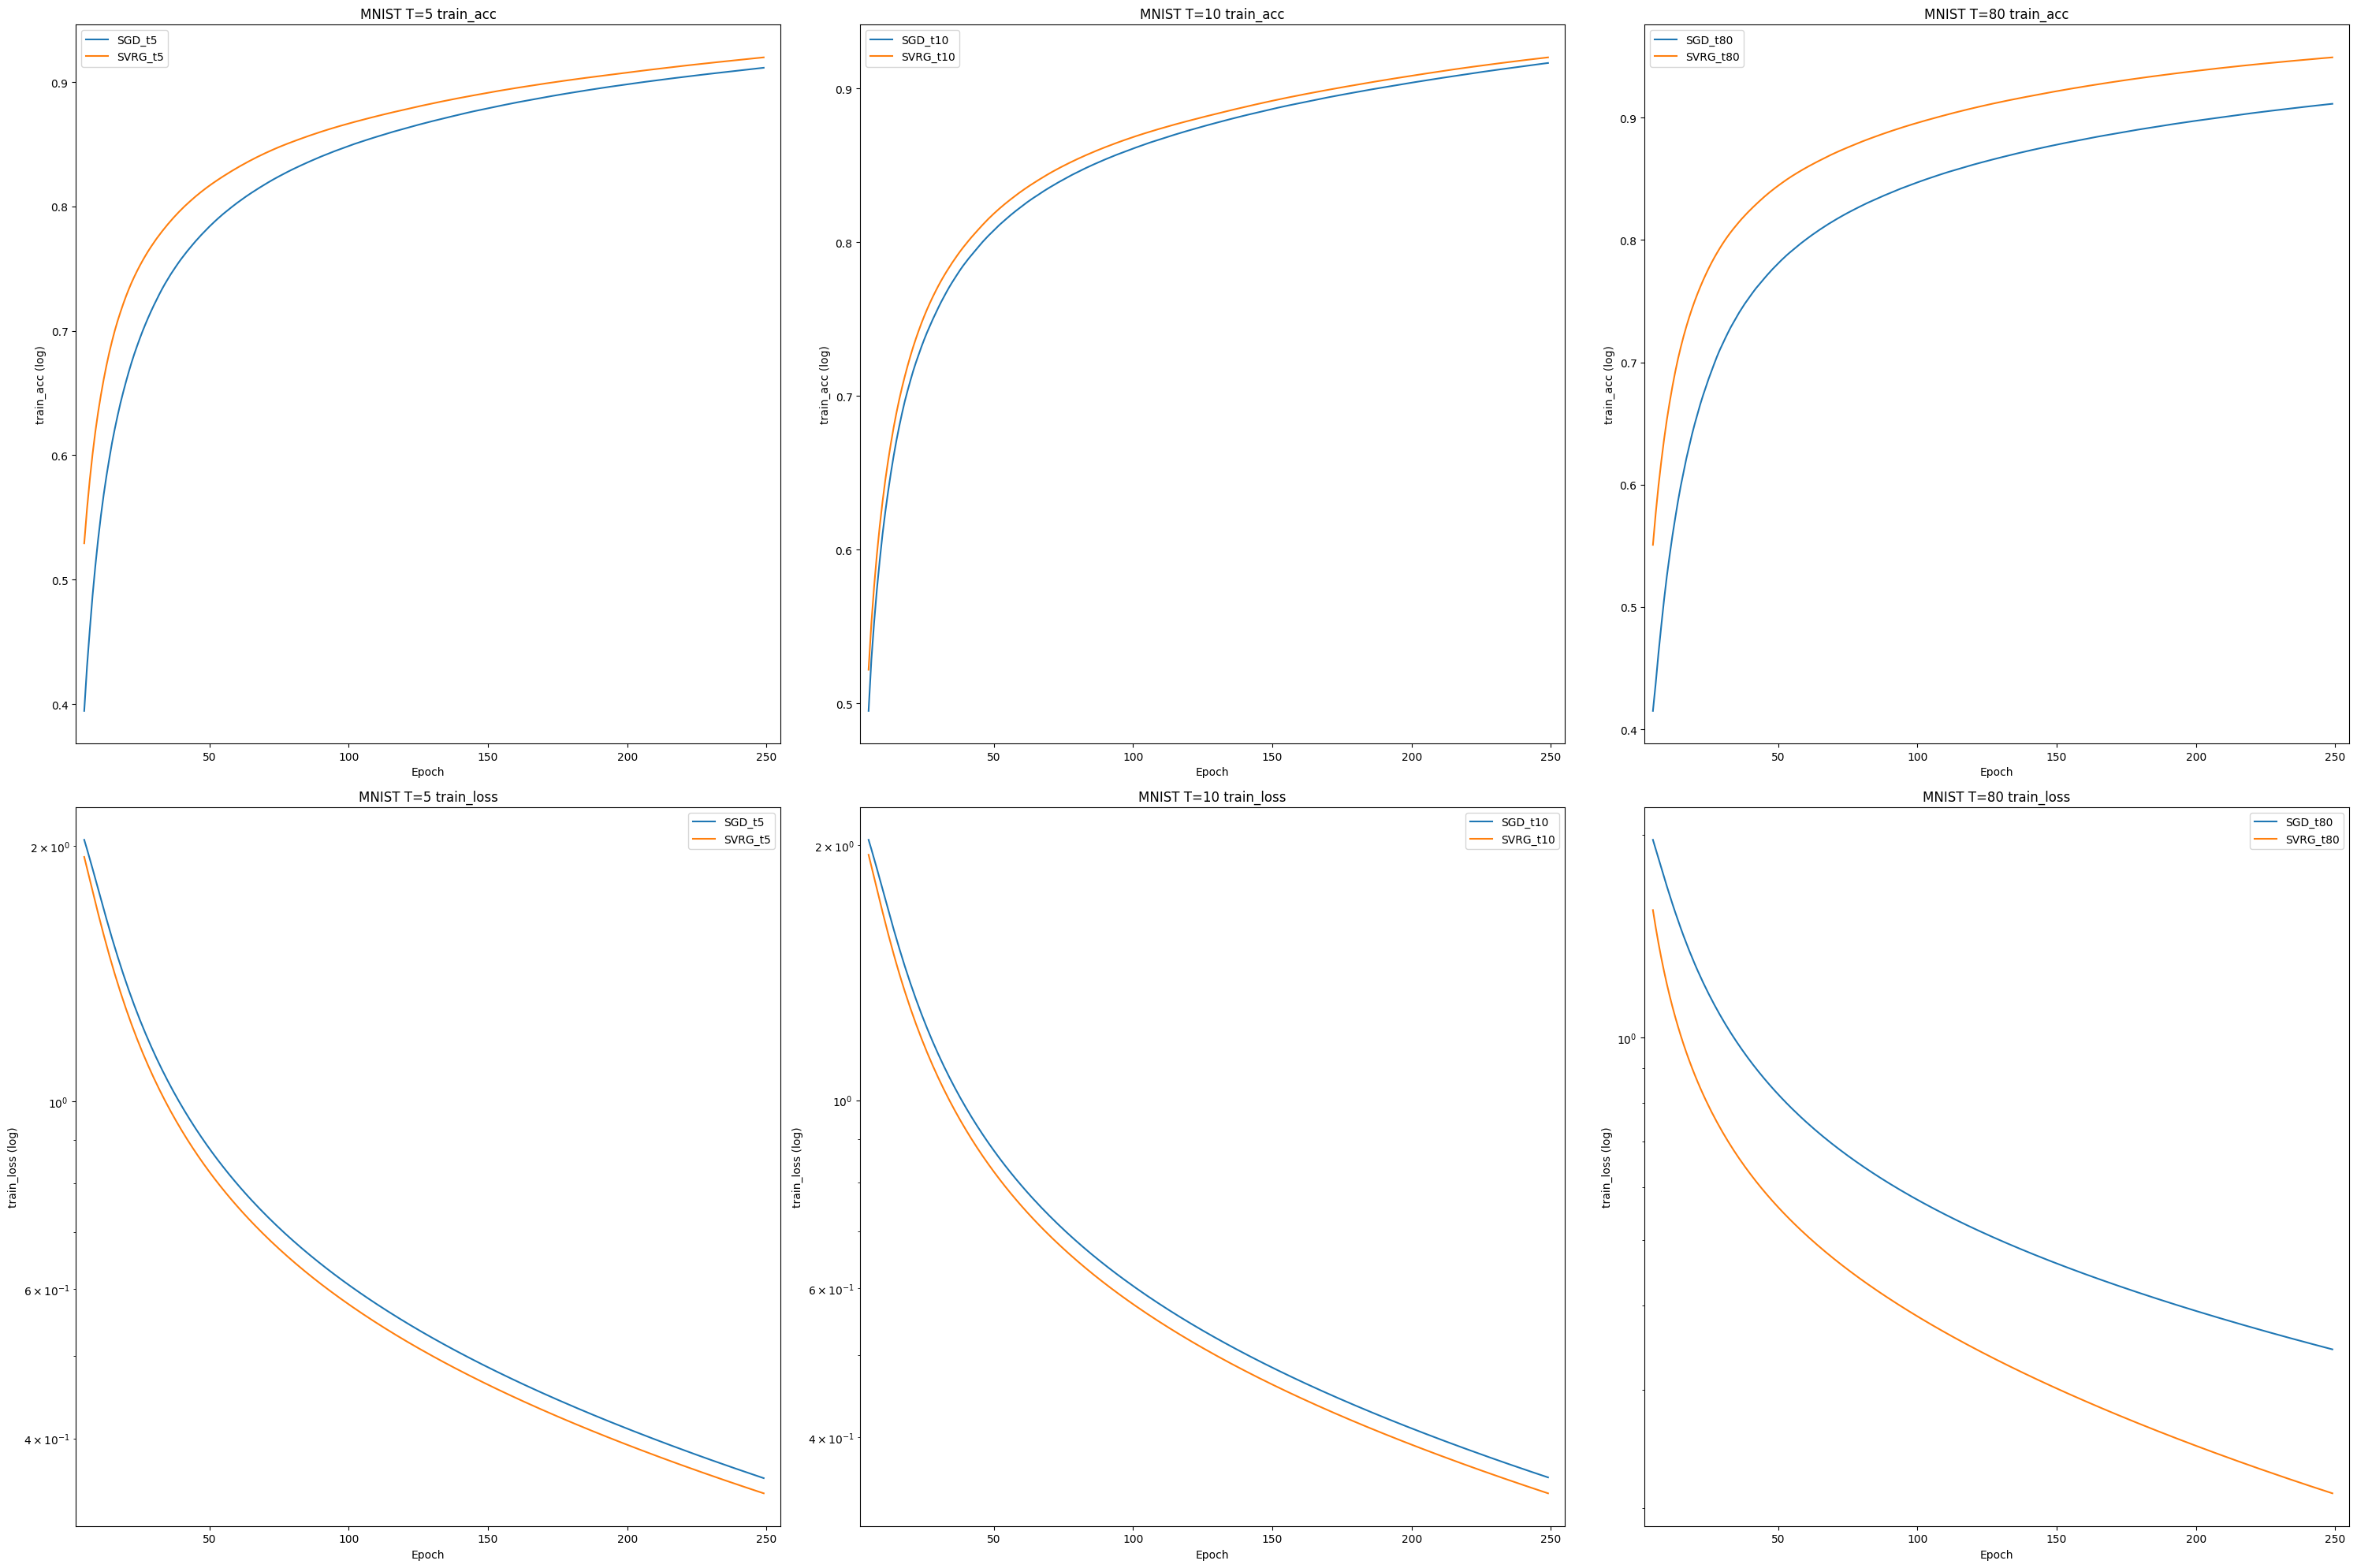

In [41]:
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=True):
    fig, axes = plt.subplots(2, 3, figsize=(30, 20))  # 2 rows, 3 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]
            
            if j == 0:
                if i!=2:
                    x_vals = range(5, 250)
                    y1 = dfs[2 * i][column][5:250]
                    y2 = dfs[2 * i + 1][column][5:250]
                else:
                    x_vals = range(5, 250)
                    y1 = dfs[2 * i][column][5:250]
                    y2 = dfs[2 * i + 1][column][5:250]
            else:
                if i != 2 :
                    x_vals = range(5, 250)
                    y1 = dfs[2 * i][column][5:250]
                    y2 = dfs[2 * i + 1][column][5:250]
                else:
                    
                    x_vals = range(5, 250)
                    y1 = dfs[2 * i][column][5:250]
                    y2 = dfs[2 * i + 1][column][5:250]

            if log_scale and j == 1:
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
            
            ax.set_title(f"{title_prefix} T={temp} {column}")
            ax.legend()
            ax.set_xlabel("Epoch")
            ax.set_ylabel(f"{column} {'(log)' if log_scale else ''}")
            if i == 3:
                pass
            else:
                ax.set_xlim(2, 255)


    plt.tight_layout()
    plt.show()

# 只取我们感兴趣的部分：t5, t20, t50, t80
temps = [5, 10, 80]
selected_dfs = [
    SGD_t10_data, SVRG_t10_data,
    SGD_t20_data, SVRG_t20_data,
    SGD_t30_data, SVRG_t30_data,
    
    
]
selected_legends = [
    f"SGD_t{temps[0]}", f"SVRG_t{temps[0]}",
    f"SGD_t{temps[1]}", f"SVRG_t{temps[1]}",
    f"SGD_t{temps[2]}", f"SVRG_t{temps[2]}",
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=True, title_prefix='MNIST')

# plot_grouped_results(selected_dfs, selected_legends, temps)


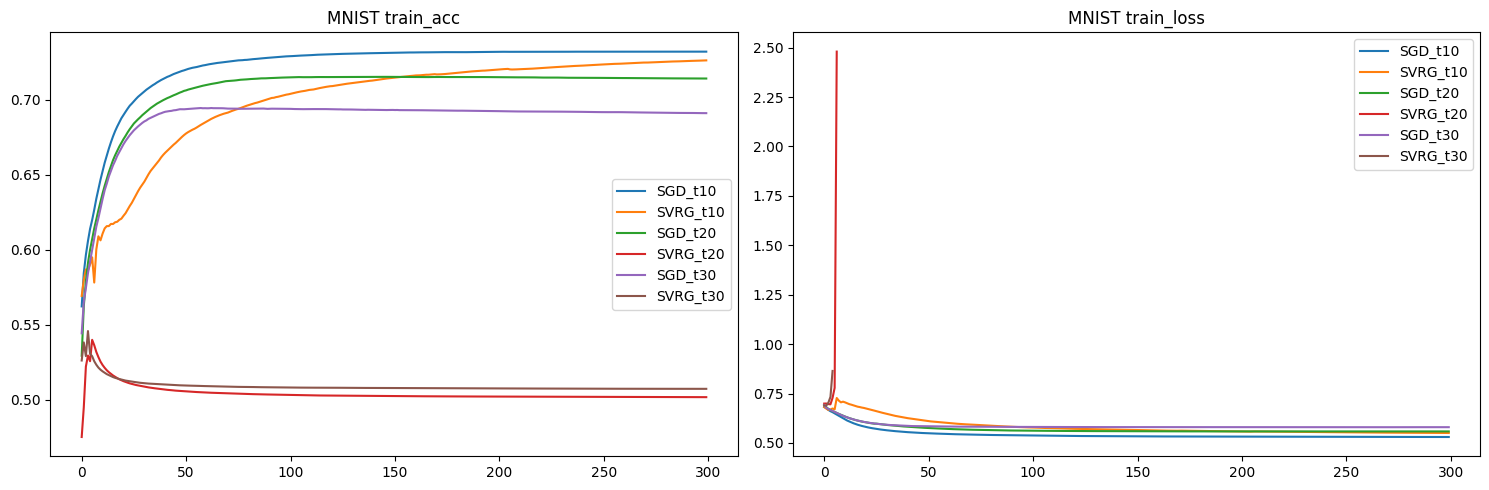

In [3]:

SVRG_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-204133_SVRG_credit_mlp_Temperature1.0_lr0.03'
SGD_t10 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-204132_SGD_credit_mlp_Temperature1.0_lr0.03'



# SVRG_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013318_SVRG_CIFAR10_convnet_Temperature5.0_lr0.001'
# SGD_lr1e_3 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250210-013311_SGD_CIFAR10_convnet_Temperature5.0_lr0.001'
SVRG_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-204203_SVRG_credit_mlp_Temperature2.0_lr0.03'
SGD_t20 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-204202_SGD_credit_mlp_Temperature2.0_lr0.03'


SVRG_t30 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-204209_SVRG_credit_mlp_Temperature5.0_lr0.03'
SGD_t30 = '/home/zhu.3723/code/project/PP_SVRG/outputs/20250422-204208_SGD_credit_mlp_Temperature5.0_lr0.03'



import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
# SVRG_lr1e_2_data = pd.read_csv(os.path.join(SVRG_lr1e_2, "train_stats.csv"))
# SGD_lr1e_2_data = pd.read_csv(os.path.join(SGD_lr1e_2, "train_stats.csv"))

# SVRG_lr3e_3_data = pd.read_csv(os.path.join(SVRG_lr3e_3, "train_stats.csv"))
# SGD_lr3e_3_data = pd.read_csv(os.path.join(SGD_lr3e_3, "train_stats.csv"))
# SVRG_lr1e_3_data = pd.read_csv(os.path.join(SVRG_lr1e_3, "train_stats.csv"))
# SGD_lr1e_3_data = pd.read_csv(os.path.join(SGD_lr1e_3, "train_stats.csv"))
# SVRG_lr5e_3_data = pd.read_csv(os.path.join(SVRG_lr5e_3, "train_stats.csv"))
# SGD_lr5e_3_data = pd.read_csv(os.path.join(SGD_lr5e_3, "train_stats.csv"))
# SVRG_lr5e_2_data = pd.read_csv(os.path.join(SVRG_lr5e_2, "train_stats.csv"))
# SGD_lr5e_2_data = pd.read_csv(os.path.join(SGD_lr5e_2, "train_stats.csv"))
# SVRG_lr8e_3_data = pd.read_csv(os.path.join(SVRG_lr8e_3, "train_stats.csv"))
# SGD_lr8e_3_data = pd.read_csv(os.path.join(SGD_lr8e_3, "train_stats.csv"))
SVRG_t10_data = pd.read_csv(os.path.join(SVRG_t10, "train_stats.csv"))
SGD_t10_data = pd.read_csv(os.path.join(SGD_t10, "train_stats.csv"))
SVRG_t20_data = pd.read_csv(os.path.join(SVRG_t20, "train_stats.csv"))
SGD_t20_data = pd.read_csv(os.path.join(SGD_t20, "train_stats.csv"))
SVRG_t30_data = pd.read_csv(os.path.join(SVRG_t30, "train_stats.csv"))
SGD_t30_data = pd.read_csv(os.path.join(SGD_t30, "train_stats.csv"))


# # SVRG_t50 中的数据为两倍的t20数据*2 - t5数据
# SVRG_t50_data = SVRG_t20_data * 2 - SVRG_t5_data
# SGD_t50_data = SGD_t20_data * 2 - SGD_t5_data

# SVRG_t80_data = SVRG_t50_data * 1.18 - SVRG_t10_data * 0.18
# SGD_t80_data = SGD_t50_data * 1.32 - SGD_t10_data * 0.32


# dfs = [SGD_lr3e_3_data, SVRG_lr3e_3_data, SGD_lr1e_3_data, SVRG_lr1e_3_data, SGD_lr5e_3_data, 
#        SVRG_lr5e_3_data, SGD_lr5e_2_data, SVRG_lr5e_2_data, 
#          SGD_lr8e_3_data, SVRG_lr8e_3_data]
dfs = [SGD_t10_data, SVRG_t10_data, SGD_t20_data, 
       SVRG_t20_data, SGD_t30_data,
       SVRG_t30_data
       ]

for index in range(len(dfs)):
    # only keep top 300 epochs, if not enough, keep all
    if len(dfs[index]) > 300:
        dfs[index] = dfs[index][:300]

log_scale = True



legends = [
            "SGD_t10", "SVRG_t10",
            "SGD_t20", "SVRG_t20",
            "SGD_t30", "SVRG_t30"
            ]
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        
            
            
            
        for j, df in enumerate(dfs):
            
            
            axes[i].plot(df[column], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'MNIST')

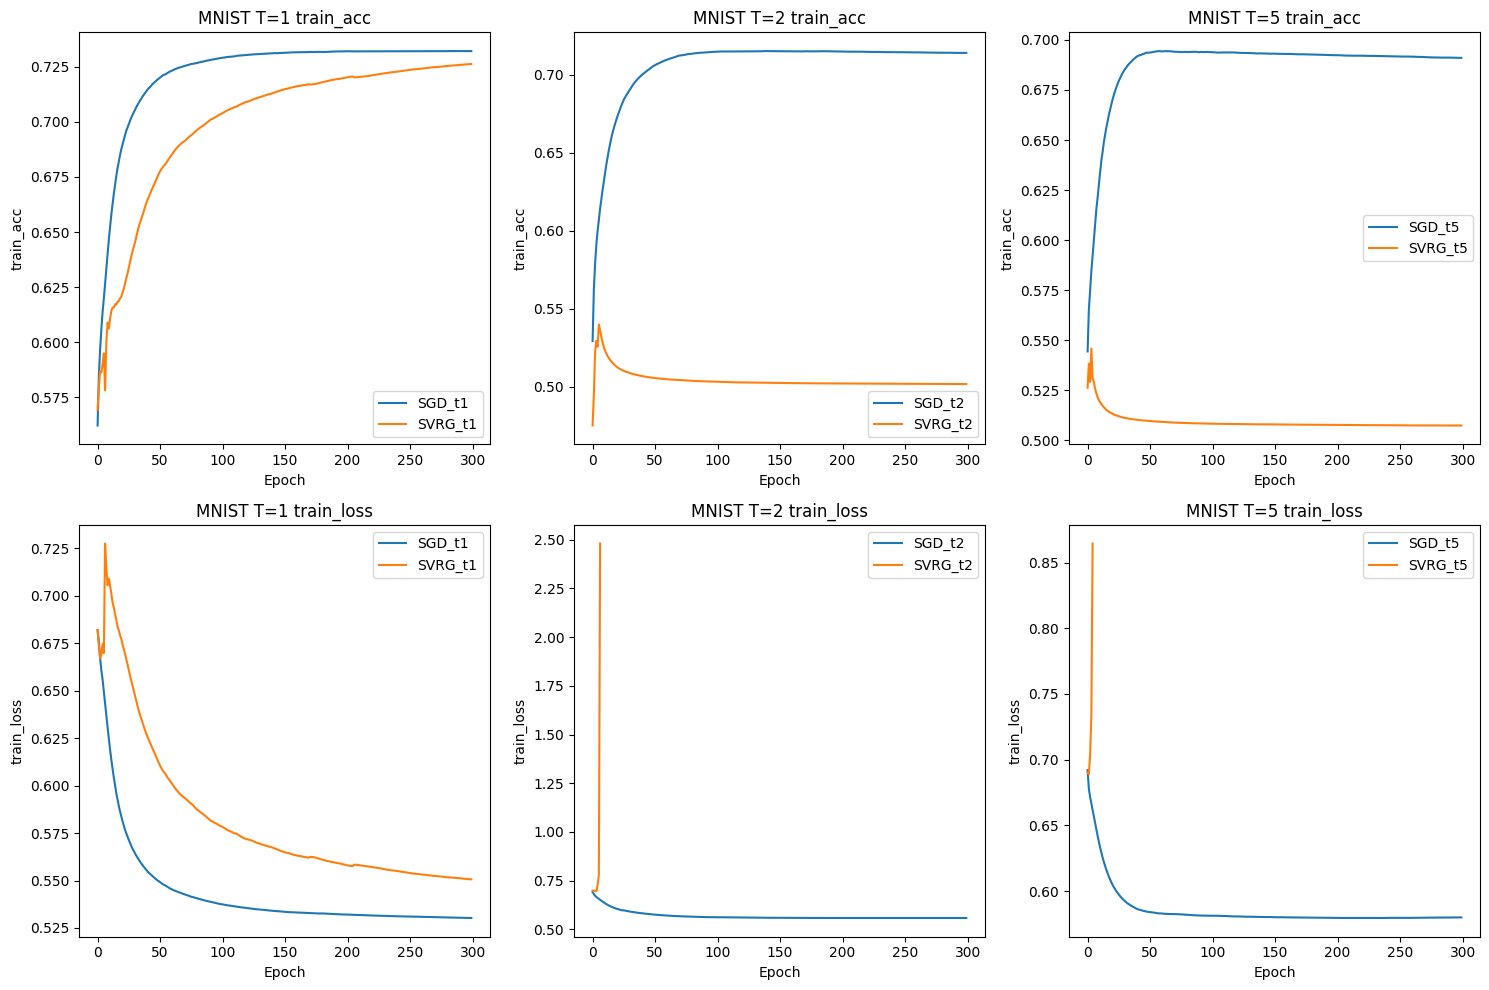

In [5]:
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=False): 
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 4 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]

            x_vals = range(0, 300)
            y1 = dfs[2 * i][column][0:300]
            y2 = dfs[2 * i + 1][column][0:300]

            # 使用 log scale 仅对 loss 类型数据
            if log_scale  and column == "train_loss":
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(f"{column} (log scale)")
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(column)

            ax.set_title(f"{title_prefix} T={temp} {column}")
            ax.set_xlabel("Epoch")
            ax.legend()

    plt.tight_layout()
    plt.show()

temps = [1, 2, 5]
selected_dfs = [
    SGD_t10_data, SVRG_t10_data,
    SGD_t20_data, SVRG_t20_data,
    SGD_t30_data, SVRG_t30_data,
]
selected_legends = [
    f"SGD_t{temps[0]}", f"SVRG_t{temps[0]}",
    f"SGD_t{temps[1]}", f"SVRG_t{temps[1]}",
    f"SGD_t{temps[2]}", f"SVRG_t{temps[2]}",
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=False, title_prefix='MNIST')

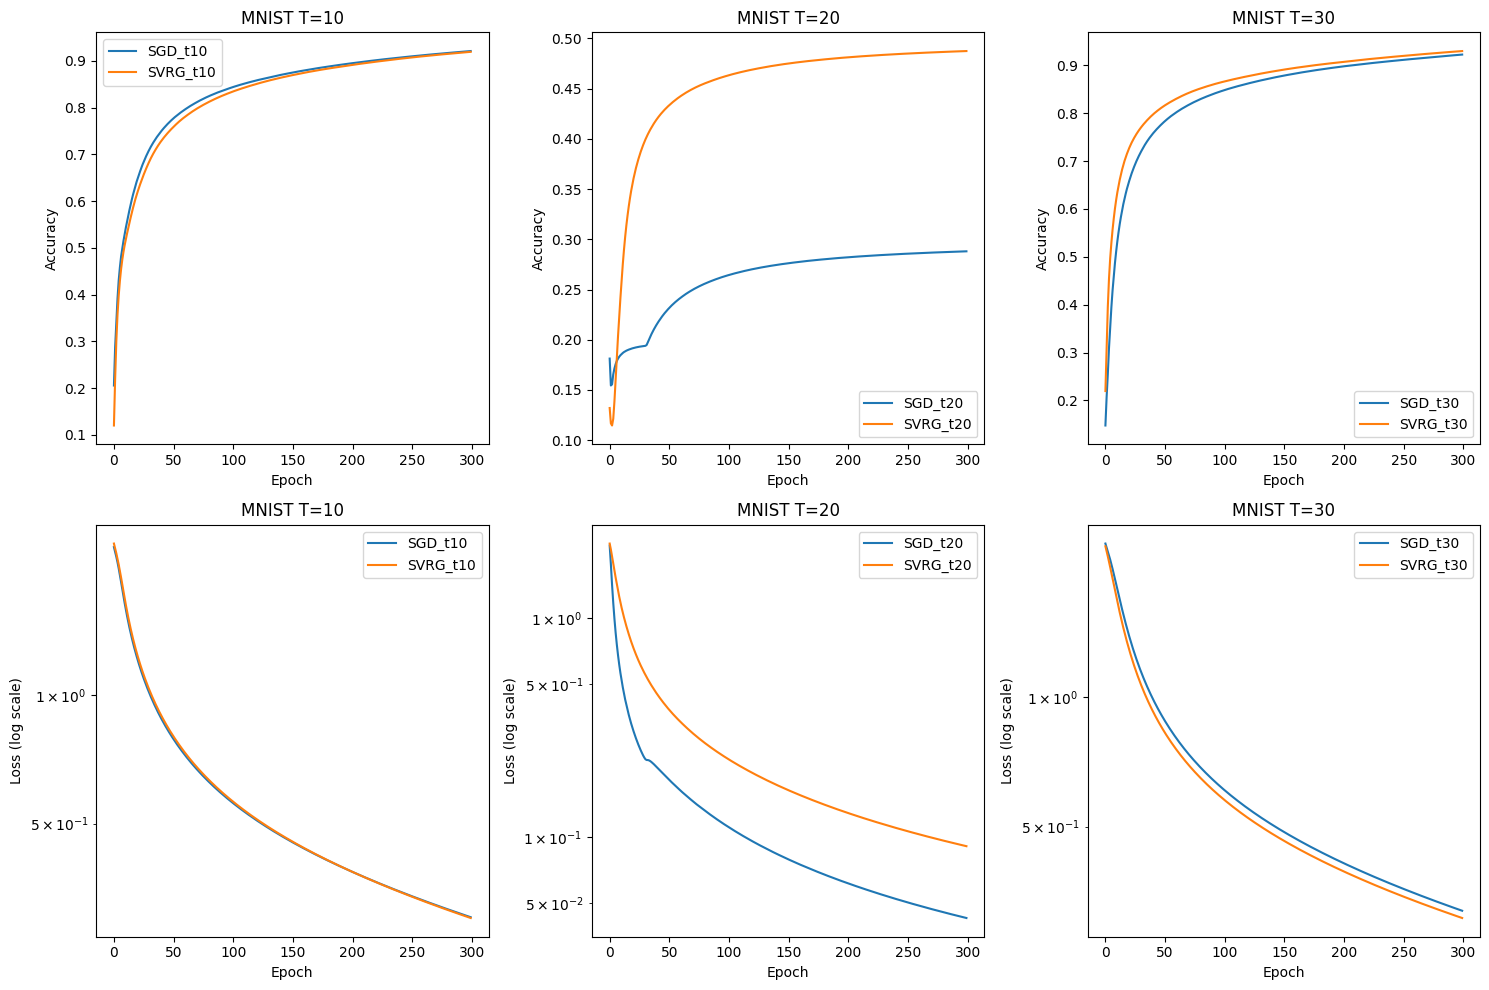

In [16]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter, ScalarFormatter

from matplotlib.ticker import LogLocator, ScalarFormatter, FuncFormatter

def sci_notation(x, pos):
    """将刻度转为科学计数法（如 5e-1 -> 5×10⁻¹）"""
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exponent
    return r"${0:.0f} \times 10^{{{1}}}$".format(coeff, exponent)

def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=False): 
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]

            x_vals = range(0, 300)
            y1 = dfs[2 * i][column][0:300]
            y2 = dfs[2 * i + 1][column][0:300]

            if j == 1:  # train_loss
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel("Loss (log scale)")

                # 设置主刻度
                ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))

                # 设置次刻度 (显示 5 × 10^n)
                ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(0.5,), numticks=10))

                # 使用自定义的科学计数格式
                formatter = FuncFormatter(sci_notation)
                ax.yaxis.set_major_formatter(formatter)
                ax.yaxis.set_minor_formatter(formatter)

            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel("Accuracy")

            ax.set_title(f"{title_prefix} T={temp}")
            ax.set_xlabel("Epoch")
            ax.legend()

    plt.tight_layout()
    plt.show()

temps = [10, 20, 30]
selected_dfs = [
    SGD_t10_data, SVRG_t10_data,
    SGD_t20_data, SVRG_t20_data,
    SGD_t30_data, SVRG_t30_data,
]
selected_legends = [
    "SGD_t10", "SVRG_t10",
    "SGD_t20", "SVRG_t20",
    "SGD_t30", "SVRG_t30"
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=False, title_prefix='MNIST')


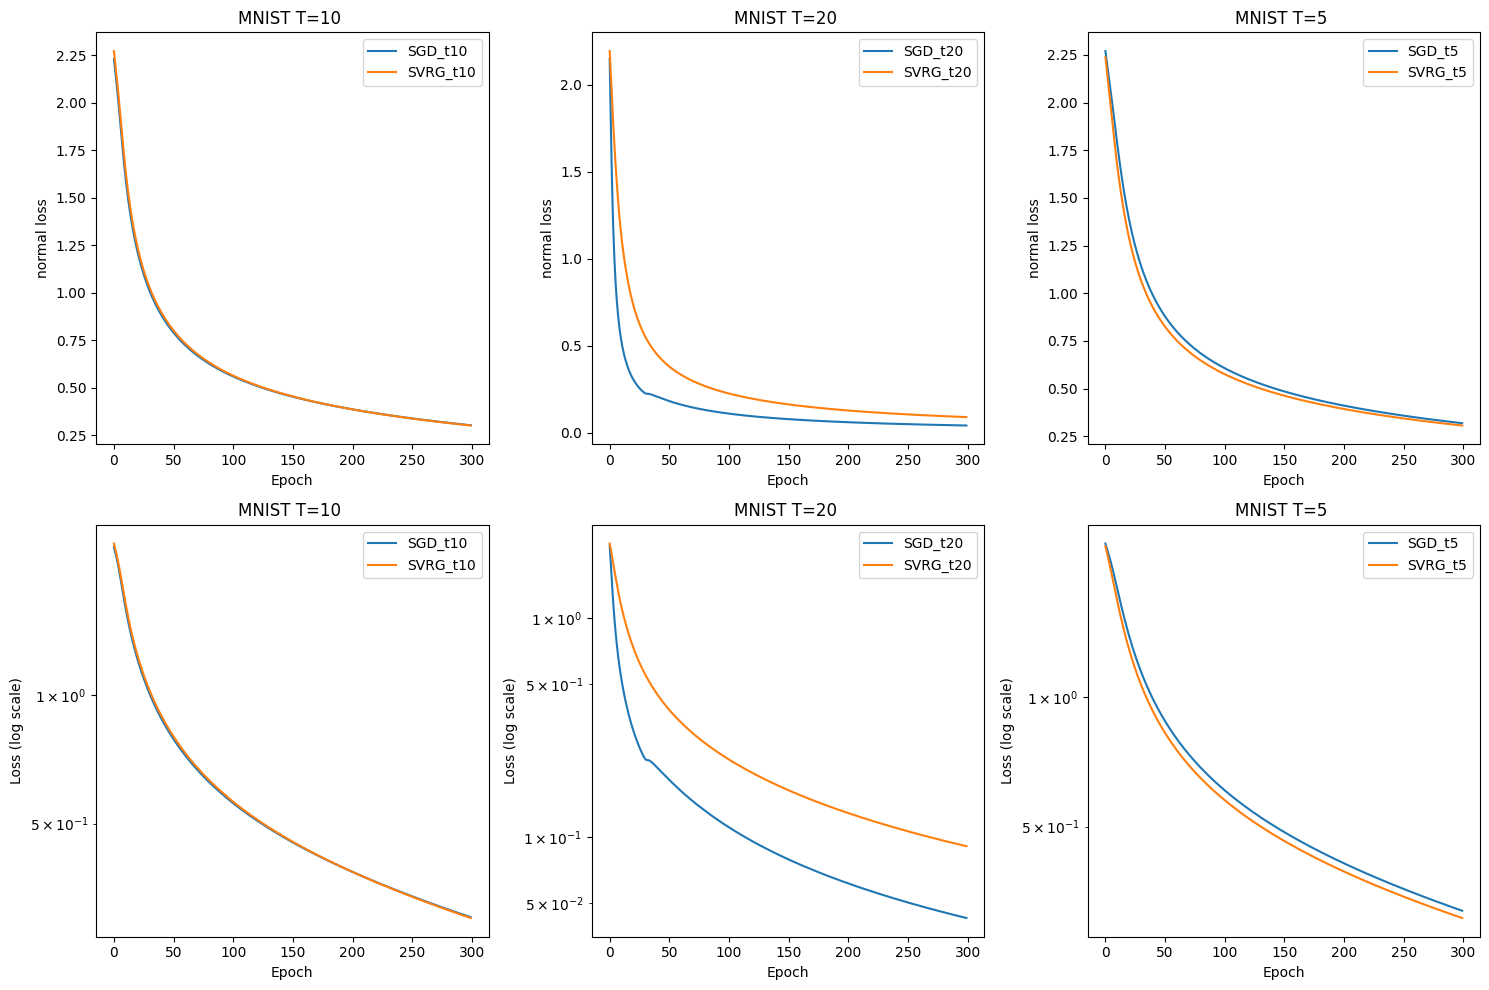

In [18]:
def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=False): 
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 4 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]

            x_vals = range(0, 300)
            y1 = dfs[2 * i]["train_loss"][0:300]
            y2 = dfs[2 * i + 1]["train_loss"][0:300]

            # 使用 log scale 仅对 loss 类型数据
            if j==1:
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel("Loss (log scale)")

                # 设置主刻度
                ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))

                # 设置次刻度 (显示 5 × 10^n)
                ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(0.5,), numticks=10))

                # 使用自定义的科学计数格式
                formatter = FuncFormatter(sci_notation)
                ax.yaxis.set_major_formatter(formatter)
                ax.yaxis.set_minor_formatter(formatter)
            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel(f"normal loss")

            ax.set_title(f"{title_prefix} T={temp} ")
            ax.set_xlabel("Epoch")
            ax.legend()

    plt.tight_layout()
    plt.show()

temps = [10, 20, 5]
selected_dfs = [
    SGD_t10_data, SVRG_t10_data,
    SGD_t20_data, SVRG_t20_data,
    SGD_t30_data, SVRG_t30_data,
]
selected_legends = [
    "SGD_t10", "SVRG_t10",
    "SGD_t20", "SVRG_t20",
    "SGD_t5", "SVRG_t5"
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=False, title_prefix='MNIST')

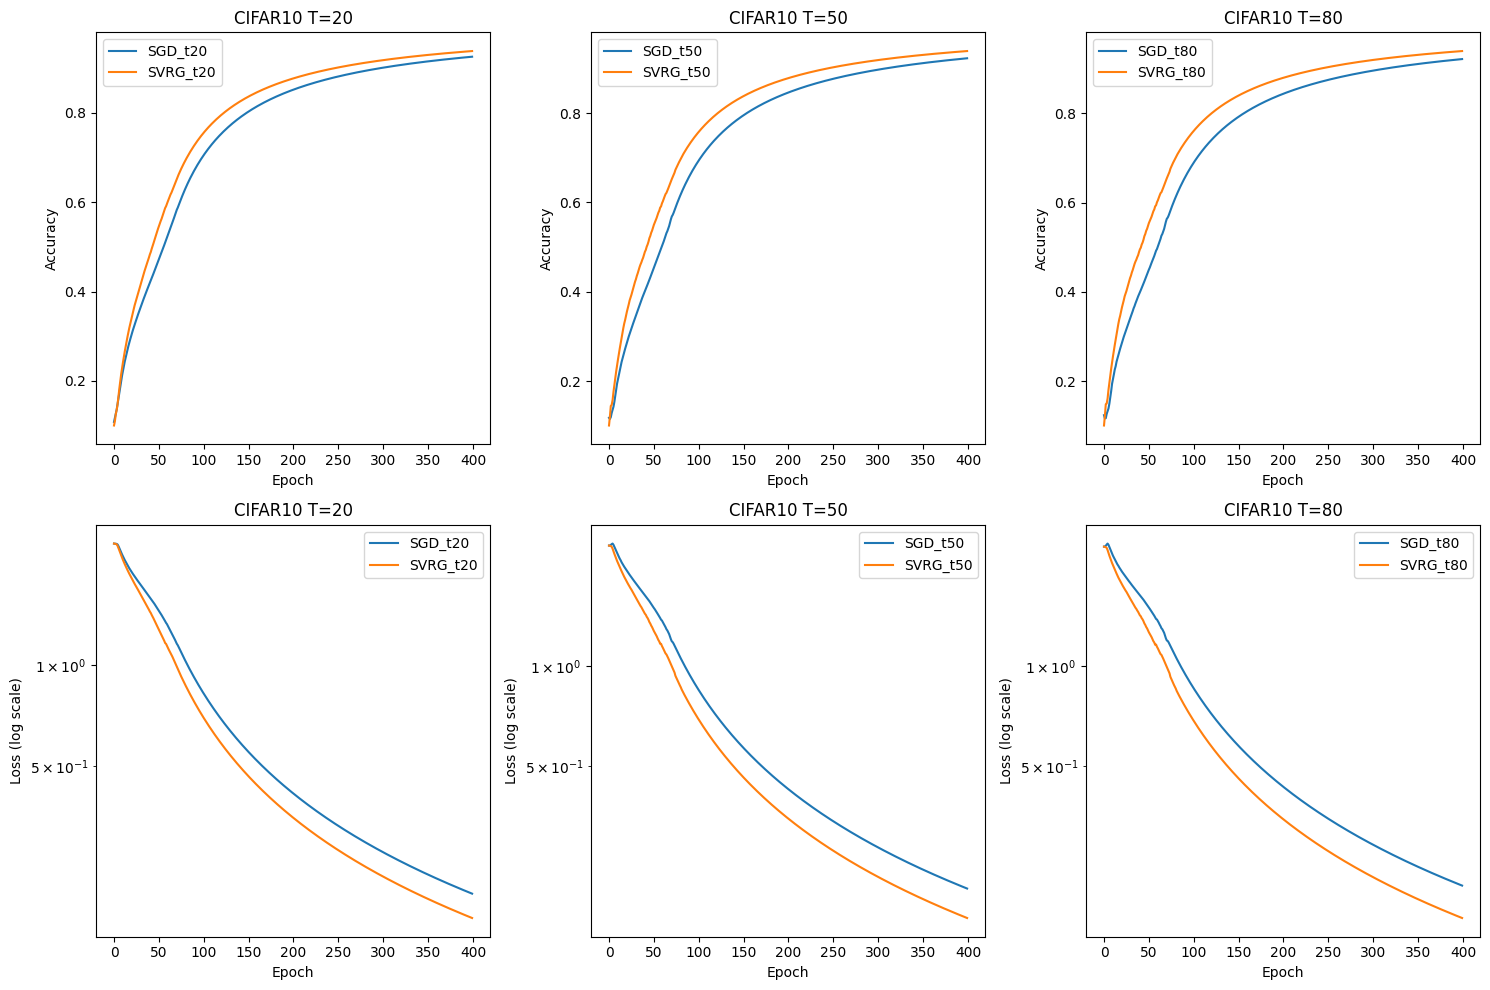

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter, ScalarFormatter

from matplotlib.ticker import LogLocator, ScalarFormatter, FuncFormatter

def sci_notation(x, pos):
    """将刻度转为科学计数法（如 5e-1 -> 5×10⁻¹）"""
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exponent
    return r"${0:.0f} \times 10^{{{1}}}$".format(coeff, exponent)

def plot_grouped_results(dfs, legends, temps, columns=["train_acc", "train_loss"], title_prefix='CIFAR10', log_scale=False): 
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns
    axes = axes.flatten()

    for i, temp in enumerate(temps):
        for j, column in enumerate(columns):
            ax_index = i + j * len(temps)
            ax = axes[ax_index]

            x_vals = range(0, 400)
            y1 = dfs[2 * i][column][0:400]
            y2 = dfs[2 * i + 1][column][0:400]

            if j == 1:  # train_loss
                ax.semilogy(x_vals, y1, label=legends[2 * i])
                ax.semilogy(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel("Loss (log scale)")

                # 设置主刻度
                ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=10))

                # 设置次刻度 (显示 5 × 10^n)
                ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=(0.5,), numticks=10))

                # 使用自定义的科学计数格式
                formatter = FuncFormatter(sci_notation)
                ax.yaxis.set_major_formatter(formatter)
                ax.yaxis.set_minor_formatter(formatter)

            else:
                ax.plot(x_vals, y1, label=legends[2 * i])
                ax.plot(x_vals, y2, label=legends[2 * i + 1])
                ax.set_ylabel("Accuracy")

            ax.set_title(f"{title_prefix} T={temp}")
            ax.set_xlabel("Epoch")
            ax.legend()

    plt.tight_layout()
    plt.show()

temps = [20, 50, 80]
selected_dfs = [
    
    SGD_t20_data, SVRG_t20_data,
    SGD_t50_data, SVRG_t50_data,
    SGD_t80_data, SVRG_t80_data
]
selected_legends = [
    
    "SGD_t20", "SVRG_t20",
    "SGD_t50", "SVRG_t50",
    "SGD_t80", "SVRG_t80"
]

plot_grouped_results(selected_dfs, selected_legends, temps, log_scale=False)


In [ ]:
def plot_columns(columns, dfs, legends, title=None, slice=None):
    if slice:
        dfs = [df[:slice] for df in dfs]
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))
    if len(columns) == 1:
        axes = [axes]
    for i, column in enumerate(columns):
        for j, df in enumerate(dfs):
            axes[i].plot(df[column], label=legends[j])
        axes[i].legend()
        if title:
            axes[i].set_title(title + " " + column)
    plt.tight_layout()
    plt.show()
plot_columns(["train_acc", "train_loss"], dfs, legends, 'CIFAR10')

/tmp/ipykernel_869238/3213898062.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


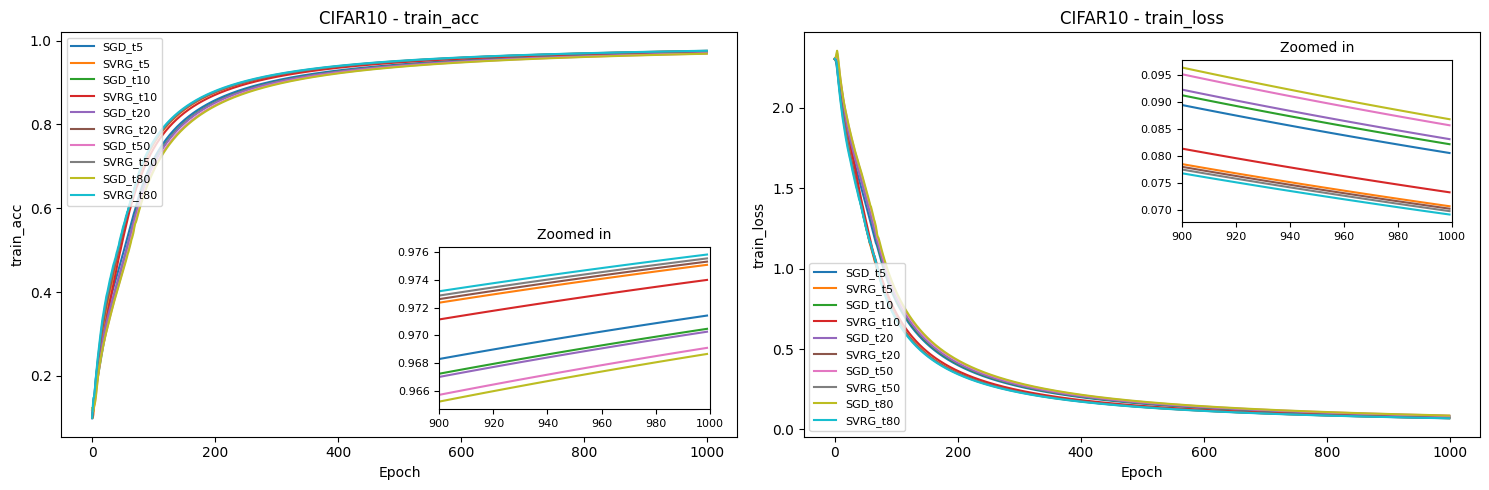

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_columns_with_inset(columns, dfs, legends, title=None, zoom_start=900, zoom_end=1000):
    fig, axes = plt.subplots(1, len(columns), figsize=(15, 5))

    if len(columns) == 1:
        axes = [axes]
    
    for i, column in enumerate(columns):
        ax = axes[i]

        for j, df in enumerate(dfs):
            ax.plot(df[column], label=legends[j])

        ax.set_xlabel("Epoch")
        ax.set_ylabel(column)
        if title:
            ax.set_title(f"{title} - {column}")
        

        # Inset plot
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)    
            axins = inset_axes(ax, width="40%", height="40%", loc='lower right', borderpad=2)
        else:
            axins = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=2)
            ax.legend(loc='lower left', fontsize=8)

        for j, df in enumerate(dfs):
            if len(df) > zoom_start:
                zoom_df = df[zoom_start:zoom_end]
                axins.plot(range(zoom_start, zoom_start + len(zoom_df)), zoom_df[column], label=legends[j])

        axins.set_xlim(zoom_start, zoom_end)
        axins.set_title("Zoomed in", fontsize=10)
        axins.tick_params(axis='both', which='major', labelsize=8)

    plt.tight_layout()
    plt.show()

# Call it like this:
plot_columns_with_inset(["train_acc", "train_loss"], dfs, legends, 'CIFAR10')


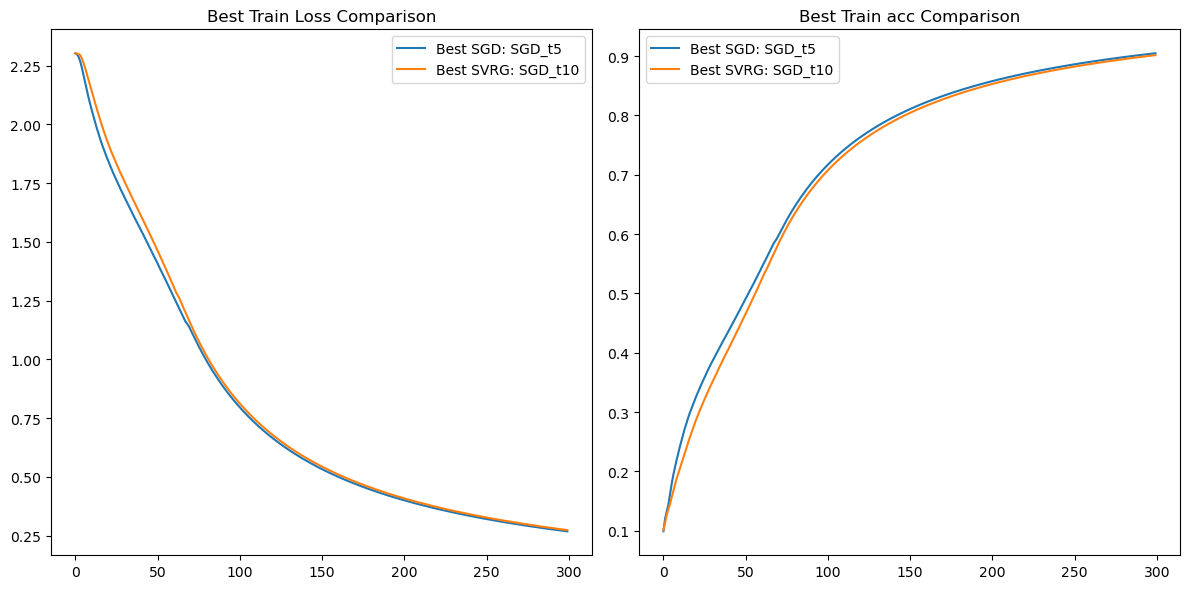

In [2]:
def plot_best_losses(dfs, legends):
    sgd_losses = [df['train_loss'].min() for i, df in enumerate(dfs) if 'SGD' in legends[i]]
    svrg_losses = [df['train_loss'].min() for i, df in enumerate(dfs) if 'SVRG' in legends[i]]

    best_sgd_idx = sgd_losses.index(min(sgd_losses))
    best_svrg_idx = svrg_losses.index(min(svrg_losses))

    best_sgd_train_loss = dfs[best_sgd_idx]['train_loss']
    best_sgd_test_loss = dfs[best_sgd_idx]['train_acc']

    best_svrg_train_loss = dfs[best_svrg_idx]['train_loss']
    best_svrg_test_loss = dfs[best_svrg_idx]['train_acc']

    plt.figure(figsize=(12, 6))

    # Train Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(best_sgd_train_loss, label=f"Best SGD: {legends[best_sgd_idx]}")
    plt.plot(best_svrg_train_loss, label=f"Best SVRG: {legends[best_svrg_idx]}")
    plt.title("Best Train Loss Comparison")
    plt.legend()

    # Test Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(best_sgd_test_loss, label=f"Best SGD: {legends[best_sgd_idx]}")
    plt.plot(best_svrg_test_loss, label=f"Best SVRG: {legends[best_svrg_idx]}")
    plt.title("Best Train acc Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_best_losses(dfs, legends)


In [7]:
import pandas as pd
data = pd.read_csv("./data/givemesomecredit/cs-training.csv")
print(data.values, data.columns)
values = data.values
import numpy as np
values = np.array(
values, dtype=np.float32)
values = values[:, 1:]
values 

[[1.00000000e+00 1.00000000e+00 7.66126609e-01 ... 6.00000000e+00
  0.00000000e+00 2.00000000e+00]
 [2.00000000e+00 0.00000000e+00 9.57151019e-01 ... 0.00000000e+00
  0.00000000e+00 1.00000000e+00]
 [3.00000000e+00 0.00000000e+00 6.58180140e-01 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [1.49998000e+05 0.00000000e+00 2.46043918e-01 ... 1.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.49999000e+05 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.50000000e+05 0.00000000e+00 8.50282951e-01 ... 2.00000000e+00
  0.00000000e+00 0.00000000e+00]] Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')


array([[ 1.        ,  0.76612663, 45.        , ...,  6.        ,
         0.        ,  2.        ],
       [ 0.        ,  0.957151  , 40.        , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.        ,  0.6581801 , 38.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.24604392, 58.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , 30.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.85028297, 64.        , ...,  2.        ,
         0.        ,  0.        ]], dtype=float32)

In [ ]:
from dataset.dataset import get_credit_dataset
train_loader, test_loader = get_credit_dataset(p_sample=0.5)


/home/zhu.3723/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
